<div align="center" style="text-align: center; padding: 60px 0;">

<h1 style="text-align: center;">Title</h1>

<br>

<h2 style="text-align: center;">Time Series Analysis</h2>

<br><br>

<p style="text-align: center; font-size: 18px;"><b>Author:</b> Luka Rondal</p>

<p style="text-align: center; font-size: 18px;">2026</p>

</div>


# Introduction

In this notebook, we analyze a time series and forecast it with two different methods.

In the first approach, we apply an ETS decomposition to split the series into its trend, seasonal and residual components. The trend and seasonality are extrapolated, while the residual $R_t$ is modeled with an ARIMA model. We then recombine the three components to obtain the final forecast and compare it with the test set.

The second approach uses Facebook Prophet, a more automated method, to produce the same forecast.

Finally, we compare both approaches using error metrics and draw conclusions.

# 0. Dataset
First of all, we need to find a suitable time series (TS). For the analysis to make sense, the TS should have three distinct components: trend, seasonality and residual.

To find a dataset, I looked into tourism, because this field usually shows seasonality (driven by holidays) as well as a long-term trend (driven by the growth of the sector).

With the help of AI, I found the [tour_occ_nim: Nights spent at tourist accommodation establishments - monthly data](https://ec.europa.eu/eurostat/web/products-datasets/-/tour_occ_nim) dataset from Eurostat. It covers many countries; we will focus on Lithuania. I first tried others countries but the trend wasn't explicit. Tourism in Lithuania has increased a lot, that's why we chose this country.

## 0.1. Import dataset
Let's start by loading the dataset into a pandas DataFrame.

The Eurostat file `estat_tour_occ_nim.tsv` is a tab-separated file in "wide" format:
- each row is one time series (2,101 series in total), identified by a composite key in the first column (`freq,c_resid,unit,nace_r2,geo`);
- each of the other columns is a month (439 columns, from `1990-01` to `2026-07`);
- it covers 45 countries or aggregates (`geo`).

We keep a single series:
- `freq = M`: monthly data
- `c_resid = TOTAL`: residents and non-residents
- `unit = NR`: number of nights spent (the other units are percentage changes)
- `nace_r2 = I551-I553`: all types of accommodation (hotels, holiday accommodation, campsites)
- `geo = LT`: Lithuania

Eurostat values are stored as strings and can carry flags, such as `b` (break in the series), `u` (low reliability) or `:` (not available). For Lithuania, the only flag is `:`, used for 169 months:
- from `1990-01` to `2003-12`: no monthly data is available for Lithuania before 2004;
- `2026-07`: the most recent month, not published yet.

We remove the flags, convert the values to numbers and drop the missing values. The resulting series has **270 monthly observations, from January 2004 to June 2026, without any gap**, so we can set an explicit monthly frequency (`MS`, month start) on the index.

In [20]:
import pandas as pd

raw = pd.read_csv("estat_tour_occ_nim.tsv", sep="\t")

# The first column is a composite key: "freq,c_resid,unit,nace_r2,geo"
key_col = raw.columns[0]
keys = raw[key_col].str.split(",", expand=True)
keys.columns = ["freq", "c_resid", "unit", "nace_r2", "geo"]
raw = pd.concat([keys, raw.drop(columns=key_col)], axis=1)

# Monthly total nights spent (residents + non-residents) in all accommodation types, in Lithuania
mask = (
    (raw["freq"] == "M")
    & (raw["c_resid"] == "TOTAL")
    & (raw["unit"] == "NR")
    & (raw["nace_r2"] == "I551-I553")
    & (raw["geo"] == "LT")
)
row = raw.loc[mask].drop(columns=keys.columns).iloc[0]

# Values are strings with Eurostat flags (e.g. "1563436 b"); ":" means missing
values = pd.to_numeric(row.str.replace(r"[^0-9.]", "", regex=True), errors="coerce")

df = pd.DataFrame({"nights": values.to_numpy()}, index=pd.to_datetime(row.index.str.strip(), format="%Y-%m"))
df.index.name = "date"
df = df.dropna()
# Explicit monthly frequency (month start), needed by statsmodels
df = df.asfreq("MS")

df

,nights
date,
2004-01-01,77111.0
2004-02-01,81826.0
2004-03-01,100774.0
2004-04-01,111915.0
2004-05-01,166392.0
...,...
2026-02-01,577562.0
2026-03-01,641277.0
2026-04-01,655191.0


## 0.2. Plot TS

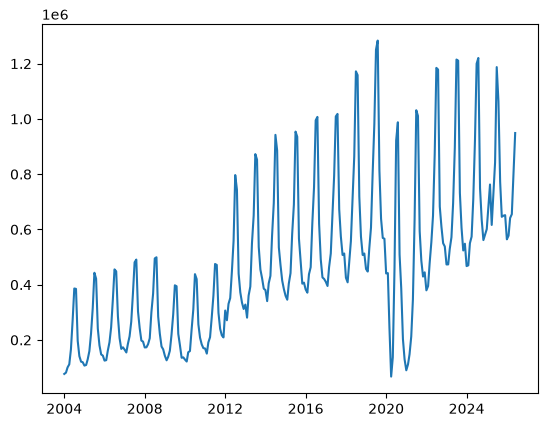

In [21]:
import matplotlib.pyplot as plt

plt.plot(df.index, df.nights)

> Seasonality?

We can clearly see regular peaks on the chart. We will dig into it later, but we should not have any problem with the seasonality aspect.

> Trend?

The average seems to grow, even if there are some bad years like 2020 and 2021 (covid).

## 0.3. train-test split
To compute the errors between our forecast and reality, we have to keep a part of the data to test our result. To do that, we will keep year 2025 + half year of 2026 as test set. I want to work with complete year so I choose 2025 and keep 2026 as bonus because it's not complete.

Train-set: 2004 -> 2024

Test-set: 2025 + 2026

In [22]:
df_train = df.loc[:"2024-12-01"]
df_test = df.loc["2025-01-01":]

print(f"Train: {df_train.index.min():%Y-%m} -> {df_train.index.max():%Y-%m} ({len(df_train)} months)")
print(f"Test:  {df_test.index.min():%Y-%m} -> {df_test.index.max():%Y-%m} ({len(df_test)} months)")

Train: 2004-01 -> 2024-12 (252 months)
Test:  2025-01 -> 2026-06 (18 months)


# 1. ETS Decomposition + ARIMA
We will perform the ETS Decomposition. Our decomposition/recomposition will follow the next steps: 
1. Determine the model (additive or multiplicative)
1. Determine if there is a trend component (Anova test)
1. Estimate the trend using CMA (Center Moving Average)
1. Detrend
1. Determine if there is a seasonal component (Anova test)
1. Forecast St and ensure area conservation is met
1. Remove seasonality, $Y_t' = R_t \cdot T_t$
1. Compute and forecast the trend (method varies depending on linearity)
1. Remove trend, $Y_t'' = R_t$
1. Forecast R_t using ARIMA model
1. Recomposition
1. Error's measurement

## 1.1. Additive or Multiplicative

In [25]:
import statsmodels.api as sm

# One window per calendar year = one full seasonal cycle (12 months), on the train set only
windows = df_train["nights"].groupby(df_train.index.year).agg(mean="mean", std="std", n="size")
windows = windows[windows["n"] == 12]

# Fit Std = a * mean + b + e
X = sm.add_constant(windows["mean"])
ols = sm.OLS(windows["std"], X).fit()
print(ols.summary().tables[1])

# t-test on H0: a = 0 at the 5% level
alpha = 0.05
a_hat = ols.params["mean"]
t_stat = ols.tvalues["mean"]
p_value = ols.pvalues["mean"]
print(f"\na = {a_hat:.4f}, t = {t_stat:.3f}, p-value = {p_value:.2e}")
if p_value < alpha:
    print("H0 rejected: the std grows with the level -> multiplicative model")
else:
    print("H0 not rejected: the std does not depend on the level -> additive model")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.878e+04   2.33e+04      2.095      0.050      40.231    9.75e+04
mean           0.3205      0.047      6.782      0.000       0.222       0.419

a = 0.3205, t = 6.782, p-value = 1.78e-06
H0 rejected: the std grows with the level -> multiplicative model


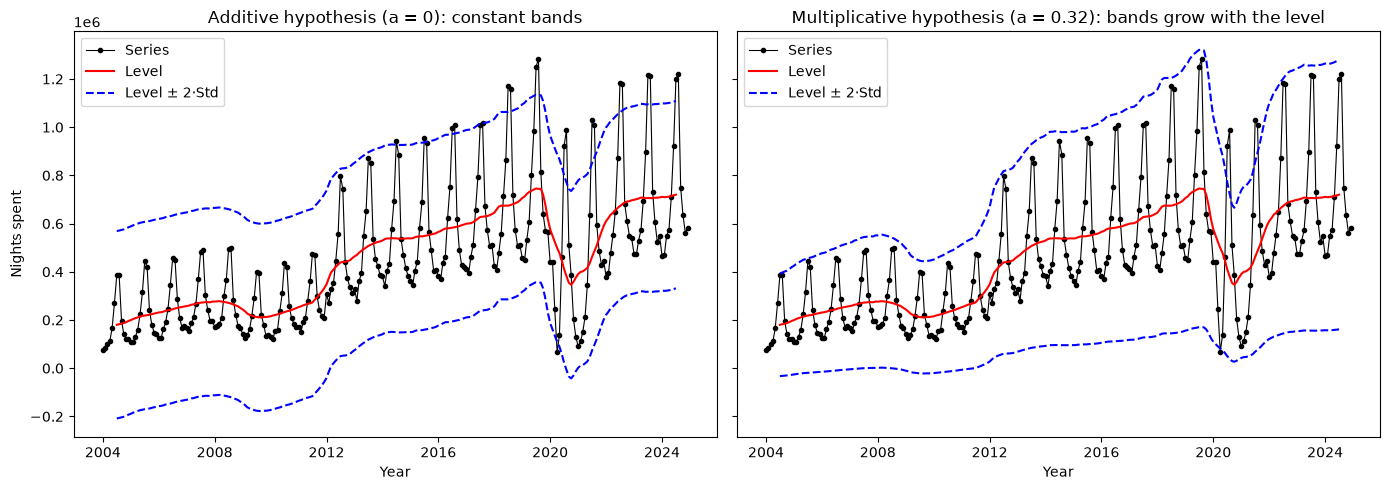

In [24]:
k = 2  # band half-width, in number of standard deviations

# Level: 12-month centered moving average
level = df_train["nights"].rolling(12, center=True).mean()

# Additive hypothesis (a = 0): constant spread, equal to the average yearly std
std_add = windows["std"].mean()
# Multiplicative hypothesis: spread proportional to the level, from the fit Std = a * mean + b
std_mult = ols.params["mean"] * level + ols.params["const"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
bands = [
    (axes[0], std_add, "Additive hypothesis (a = 0): constant bands"),
    (axes[1], std_mult, f"Multiplicative hypothesis (a = {a_hat:.2f}): bands grow with the level"),
]
for ax, spread, title in bands:
    ax.plot(df_train.index, df_train["nights"], color="black", marker=".", linewidth=0.8, label="Series")
    ax.plot(level.index, level, color="red", label="Level")
    ax.plot(level.index, level + k * spread, color="blue", linestyle="--", label=f"Level ± {k}·Std")
    ax.plot(level.index, level - k * spread, color="blue", linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.legend(loc="upper left")
axes[0].set_ylabel("Nights spent")
plt.tight_layout()
plt.show()

> Additive or multiplicative ?

The t-test has rejected a=0 hypothesis. This mean that we are in a multiplicative model. Graphically, the Std is not parallel to the average but depend on it.

TS's model: $Y_t = R_t \cdot S_t \cdot T_t$

## 1.2. Trend Component

### 1.2.1. Is there a trend ?
We'll perform an Anova test on the average nights spent per year to determine if there is a trend or not.

month,1,2,3,4,5,6,7,8,9,10,11,12,Average
year,,,,,,,,,,,,,
2004,77111.0,81826.0,100774.0,111915.0,166392.0,271291.0,386380.0,384842.0,196724.0,141493.0,121546.0,119612.0,179992.0
2005,107281.0,109599.0,129515.0,159774.0,223286.0,315612.0,443165.0,421827.0,241123.0,180634.0,147594.0,143547.0,218580.0
2006,125339.0,126957.0,160867.0,191794.0,246160.0,345830.0,455449.0,448361.0,285651.0,206964.0,167698.0,173542.0,244551.0
2007,164868.0,154812.0,185491.0,213476.0,265916.0,368950.0,481008.0,490953.0,302914.0,243283.0,197804.0,194186.0,271972.0
2008,172919.0,173507.0,184373.0,206291.0,300343.0,367637.0,495118.0,499264.0,284787.0,222683.0,176345.0,166072.0,270778.0
2009,142450.0,126446.0,138740.0,160987.0,218393.0,292812.0,397804.0,394435.0,222153.0,181216.0,135507.0,137171.0,212343.0
2010,128968.0,121981.0,155705.0,159833.0,237292.0,310795.0,438277.0,420081.0,256647.0,208323.0,183773.0,170460.0,232678.0
2011,169156.0,150631.0,191054.0,210121.0,280428.0,360443.0,474983.0,471528.0,298018.0,240367.0,216607.0,209258.0,272716.0
2012,306556.0,271381.0,330493.0,351654.0,446184.0,558369.0,796796.0,744330.0,439981.0,372492.0,335009.0,312318.0,438797.0


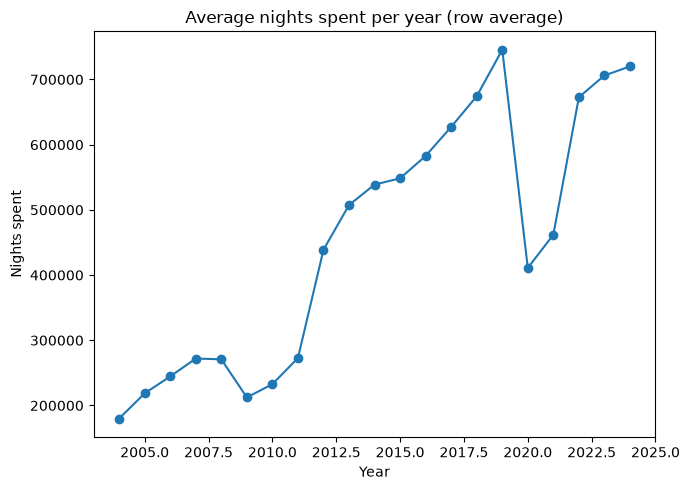

In [30]:
# Buys-Ballot table on the train set: years as rows, months as columns
long = pd.DataFrame(
    {"nights": df_train["nights"], "year": df_train.index.year, "month": df_train.index.month}
)
table = long.pivot(index="year", columns="month", values="nights")

year_mean = table.mean(axis=1)  # average by row
month_mean = table.mean(axis=0)  # average by column

# Display the table with the averages as margins
display_table = table.copy()
display_table["Average"] = year_mean
display_table.loc["Average"] = pd.concat([month_mean, pd.Series({"Average": table.stack().mean()})])
display(display_table.round(0))

fig, axes = plt.subplots(1, 1, figsize=(7, 5))
axes.plot(year_mean.index, year_mean, marker="o")
axes.set_title("Average nights spent per year (row average)")
axes.set_xlabel("Year")
axes.set_ylabel("Nights spent")
plt.tight_layout()
plt.show()

In [27]:
import statsmodels.formula.api as smf

# Two-way Anova on the Buys-Ballot table (year + month factors, no interaction).
# The month factor absorbs the seasonality, so the year factor tests
# H0: all yearly means are equal (no trend) against H1: at least one differs.
anova_fit = smf.ols("nights ~ C(year) + C(month)", data=long).fit()
anova = sm.stats.anova_lm(anova_fit)
print(anova)

f_year = anova.loc["C(year)", "F"]
p_year = anova.loc["C(year)", "PR(>F)"]
print(f"\nYear factor: F = {f_year:.2f}, p-value = {p_year:.2e}")
if p_year < alpha:
    print("H0 rejected: the yearly means differ -> there is a trend")
else:
    print("H0 not rejected: the yearly means are equal -> no trend")

             df        sum_sq       mean_sq           F        PR(>F)
C(year)    20.0  9.176918e+12  4.588459e+11   64.343073  2.838829e-80
C(month)   11.0  8.379120e+12  7.617382e+11  106.817070  8.854862e-82
Residual  220.0  1.568873e+12  7.131240e+09         NaN           NaN

Year factor: F = 64.34, p-value = 2.84e-80
H0 rejected: the yearly means differ -> there is a trend


> Is there a trend ?

The row averages grow from about 180 000 nights per month in 2004 to about 720 000 in 2024, with two visible breaks: the 2009 financial crisis, the 2020-2021 COVID years. The column averages show the seasonal profile, with a clear peak in July-August.

The Anova test rejects H0 (p-value far below 5%): the yearly means are not all equal, so **there is a trend component** in the series.

### 1.2.2. Estimate the trend
To do so, we'll compute a CMA(12) to obtain a smooth trend. We choose 12 because it is the number of components in a year (12 months).

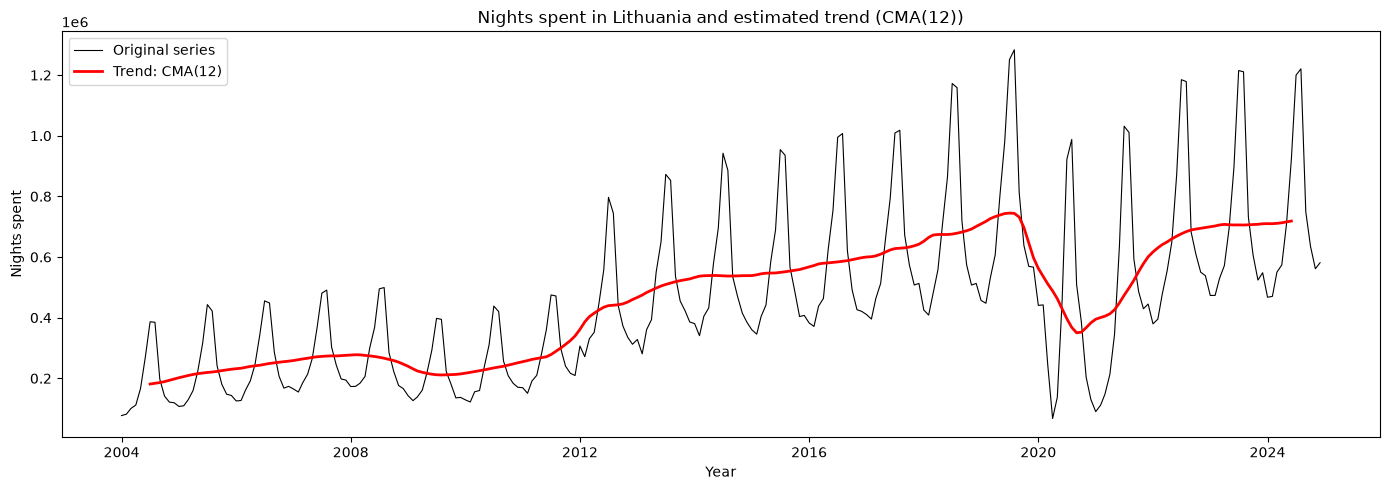

In [31]:
# CMA(12): the order is even, so a plain 12-month window is not centered on a month.
# We use a 2x12 moving average, i.e. weights [1/24, 1/12, ..., 1/12, 1/24] over 13 months,
# which is centered on month t and covers exactly one year.
# The first and last 6 months have no CMA value.
cma = df_train["nights"].rolling(12).mean().rolling(2).mean().shift(-6)
df_train = df_train.assign(cma=cma)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_train.index, df_train["nights"], color="black", linewidth=0.8, label="Original series")
ax.plot(df_train.index, df_train["cma"], color="red", linewidth=2, label="Trend: CMA(12)")
ax.set_title("Nights spent in Lithuania and estimated trend (CMA(12))")
ax.set_xlabel("Year")
ax.set_ylabel("Nights spent")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

> Trend

The red line is our estimated trend. It has been obtained with a CMA(12) on the original Time Series. Doing that, we lose the 6 first points and the 6 last points. This is not a problem because we still have a lot of points to compute our average by season.

### 1.2.3. Detrend
We will remove the trend to our original Time Series to be able to decompose the seasonal component. We have a multiplicative model so we need to divide our original TS by the estimated trend. 

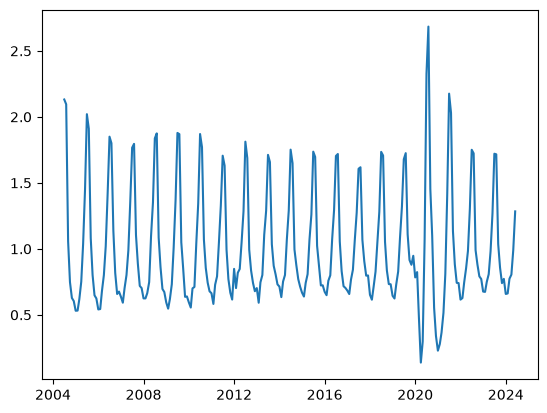

In [37]:
# Multiplicative model: Y_t / T_t = S_t * R_t
# The CMA is NaN for the first and last 6 months, so the ratio is NaN there too
df_train = df_train.assign(seasonal_residual=df_train["nights"] / df_train["cma"])

plt.plot(df_train.index, df_train.seasonal_residual)

## 1.3. Seasonal Component

### 1.3.1. Is there a seasonal component ?
We'll perform an Anova test on the average nights spent per months to determine if there is a seasonal component or not.

month,1,2,3,4,5,6,7,8,9,10,11,12,Average
year,,,,,,,,,,,,,
2004,NaN,NaN,NaN,NaN,NaN,NaN,2.132,2.095,1.058,0.748,0.628,0.605,1.211
2005,0.531,0.532,0.619,0.751,1.036,1.451,2.021,1.910,1.082,0.801,0.648,0.624,1.000
2006,0.541,0.544,0.681,0.802,1.021,1.421,1.850,1.801,1.137,0.818,0.658,0.676,0.996
2007,0.637,0.592,0.703,0.802,0.989,1.361,1.766,1.796,1.105,0.889,0.719,0.703,1.005
2008,0.625,0.625,0.665,0.748,1.096,1.352,1.837,1.875,1.085,0.861,0.696,0.673,1.011
2009,0.594,0.547,0.619,0.732,1.009,1.371,1.878,1.869,1.050,0.854,0.636,0.640,0.983
2010,0.595,0.555,0.701,0.711,1.041,1.344,1.870,1.771,1.070,0.856,0.743,0.679,0.995
2011,0.664,0.583,0.728,0.792,1.046,1.330,1.706,1.630,0.993,0.771,0.667,0.616,0.961
2012,0.848,0.703,0.819,0.848,1.049,1.285,1.812,1.688,0.994,0.836,0.742,0.679,1.025


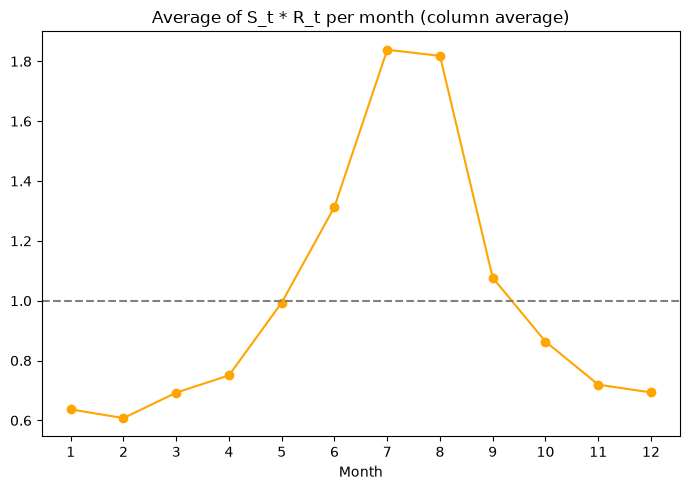

In [40]:
# Buys-Ballot table of the detrended series (S_t * R_t): years as rows, months as columns
# The first 6 and last 6 months are NaN (no CMA value), so they are dropped
detrended = df_train["seasonal_residual"].dropna()
long_s = pd.DataFrame(
    {"seasonal_residual": detrended, "year": detrended.index.year, "month": detrended.index.month}
)
table_s = long_s.pivot(index="year", columns="month", values="seasonal_residual")

year_mean_s = table_s.mean(axis=1)  # average by row
month_mean_s = table_s.mean(axis=0)  # average by column

# Display the table with the averages as margins
display_table_s = table_s.copy()
display_table_s["Average"] = year_mean_s
display_table_s.loc["Average"] = pd.concat([month_mean_s, pd.Series({"Average": table_s.stack().mean()})])
display(display_table_s.round(3))

fig, axes = plt.subplots(1, 1, figsize=(7, 5))
axes.plot(month_mean_s.index, month_mean_s, marker="o", color="orange")
axes.axhline(1, color="grey", linestyle="--")
axes.set_title("Average of S_t * R_t per month (column average)")
axes.set_xlabel("Month")
axes.set_xticks(range(1, 13))
plt.tight_layout()
plt.show()

In [41]:
# One-way Anova with the month as factor, on the detrended series.
# H0: all monthly means are equal (no seasonality) against H1: at least one differs.
anova_s_fit = smf.ols("seasonal_residual ~ C(month)", data=long_s).fit()
anova_s = sm.stats.anova_lm(anova_s_fit)
print(anova_s)

f_month = anova_s.loc["C(month)", "F"]
p_month = anova_s.loc["C(month)", "PR(>F)"]
print(f"\nMonth factor: F = {f_month:.2f}, p-value = {p_month:.2e}")
if p_month < alpha:
    print("H0 rejected: the monthly means differ -> there is a seasonal component")
else:
    print("H0 not rejected: the monthly means are equal -> no seasonal component")

             df     sum_sq   mean_sq           F         PR(>F)
C(month)   11.0  42.203362  3.836669  204.500072  1.921911e-111
Residual  228.0   4.277556  0.018761         NaN            NaN

Month factor: F = 204.50, p-value = 1.92e-111
H0 rejected: the monthly means differ -> there is a seasonal component


> Is there a seasonal component ?

The column averages show a clear seasonal profile. The summer months are far above the trend (about 1.84 in July and 1.82 in August), while the winter months are far below it (about 0.61 in February and 0.64 in January).

The Anova test rejects H0 (p-value far below 5%): the monthly means are not all equal, so **there is a seasonal component** in the series.

If we have a look to the average of average, it equals 1.000. This is random, nothing ensure that area conservation is met for the moment. We'll implement it to be sure that this code work with a different TS.

### 1.3.2. Forecast and area conservation
We almost forecast our seasonal component, but we need to ensure the area conservation is met. It shouldn't change a lot because fortunately our average of average is 1. But this is just lucky. 

In [42]:
# Area conservation: divide each monthly average by the average of averages,
# so that the 12 seasonal coefficients average exactly 1 (sum = 12)
average_of_average = month_mean_s.mean()
seasonal_coef = month_mean_s / average_of_average

# New row in the matrix with the seasonal coefficients
display_table_s.loc["Seasonal coefficient"] = pd.concat(
    [seasonal_coef, pd.Series({"Average": seasonal_coef.mean()})]
)
display(display_table_s.round(3))

print(f"Average of averages before correction: {average_of_average:.6f}")
print(f"Sum of the seasonal coefficients: {seasonal_coef.sum():.6f}")

# Seasonal component S_t: each month gets the coefficient of its calendar month.
# Unlike the CMA, it is defined for every month, including the first and last 6.
df_train = df_train.assign(seasonal=df_train.index.month.map(seasonal_coef).to_numpy())

df_train

month,1,2,3,4,5,6,7,8,9,10,11,12,Average
year,,,,,,,,,,,,,
2004,NaN,NaN,NaN,NaN,NaN,NaN,2.132,2.095,1.058,0.748,0.628,0.605,1.211
2005,0.531,0.532,0.619,0.751,1.036,1.451,2.021,1.910,1.082,0.801,0.648,0.624,1.000
2006,0.541,0.544,0.681,0.802,1.021,1.421,1.850,1.801,1.137,0.818,0.658,0.676,0.996
2007,0.637,0.592,0.703,0.802,0.989,1.361,1.766,1.796,1.105,0.889,0.719,0.703,1.005
2008,0.625,0.625,0.665,0.748,1.096,1.352,1.837,1.875,1.085,0.861,0.696,0.673,1.011
2009,0.594,0.547,0.619,0.732,1.009,1.371,1.878,1.869,1.050,0.854,0.636,0.640,0.983
2010,0.595,0.555,0.701,0.711,1.041,1.344,1.870,1.771,1.070,0.856,0.743,0.679,0.995
2011,0.664,0.583,0.728,0.792,1.046,1.330,1.706,1.630,0.993,0.771,0.667,0.616,0.961
2012,0.848,0.703,0.819,0.848,1.049,1.285,1.812,1.688,0.994,0.836,0.742,0.679,1.025


Average of averages before correction: 1.000454
Sum of the seasonal coefficients: 12.000000


,nights,cma,seasonal_residual,seasonal
date,,,,
2004-01-01,77111.0,NaN,NaN,0.636560
2004-02-01,81826.0,NaN,NaN,0.607570
2004-03-01,100774.0,NaN,NaN,0.692519
2004-04-01,111915.0,NaN,NaN,0.750300
2004-05-01,166392.0,NaN,NaN,0.993336
...,...,...,...,...
2024-08-01,1220439.0,NaN,NaN,1.817285
2024-09-01,748968.0,NaN,NaN,1.076086
2024-10-01,635245.0,NaN,NaN,0.863166


> Seasonal component

We forecasted our seasonal component. As we can see we don't have any NaN value remaining, because the seasonal component repeat itself each Years. 

### 1.3.3. Remove Seasonality
We are now able to compute a TS with the trend and the residual component. Based on this we'll forecast the trend.

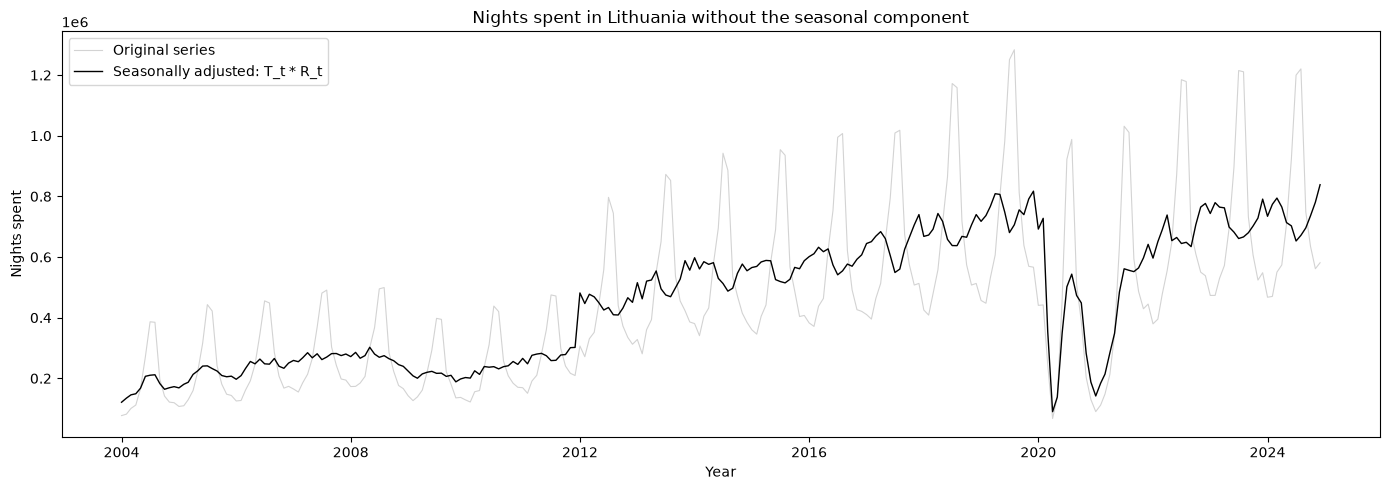

,nights,cma,seasonal_residual,seasonal,trend_residual
date,,,,,
2004-01-01,77111.0,NaN,NaN,0.636560,121137.122461
2004-02-01,81826.0,NaN,NaN,0.607570,134677.562883
2004-03-01,100774.0,NaN,NaN,0.692519,145518.107642
2004-04-01,111915.0,NaN,NaN,0.750300,149160.344702
2004-05-01,166392.0,NaN,NaN,0.993336,167508.305148
...,...,...,...,...,...
2024-08-01,1220439.0,NaN,NaN,1.817285,671572.722154
2024-09-01,748968.0,NaN,NaN,1.076086,696011.491519
2024-10-01,635245.0,NaN,NaN,0.863166,735947.819223


In [43]:
# Multiplicative model: Y_t / S_t = T_t * R_t
# The seasonal component is defined for every month, so there is no NaN here
df_train = df_train.assign(trend_residual=df_train["nights"] / df_train["seasonal"])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_train.index, df_train["nights"], color="lightgrey", linewidth=0.8, label="Original series")
ax.plot(df_train.index, df_train["trend_residual"], color="black", linewidth=1, label="Seasonally adjusted: T_t * R_t")
ax.set_title("Nights spent in Lithuania without the seasonal component")
ax.set_xlabel("Year")
ax.set_ylabel("Nights spent")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

df_train

## 1.4. Trend forecasting

### 1.4.1. Linear 
We'll try to fit a linear trend because the global growth looks a bit linear. The points that doesn't match are due to worldwide issues (like covid on 2020 and 2021).

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.604e+05   1.53e+04     10.514      0.000     1.3e+05     1.9e+05
x1          2343.8343    104.542     22.420      0.000    2137.939    2549.729

T_t = 2343.83 * t + 160388.74   (R² = 0.668)


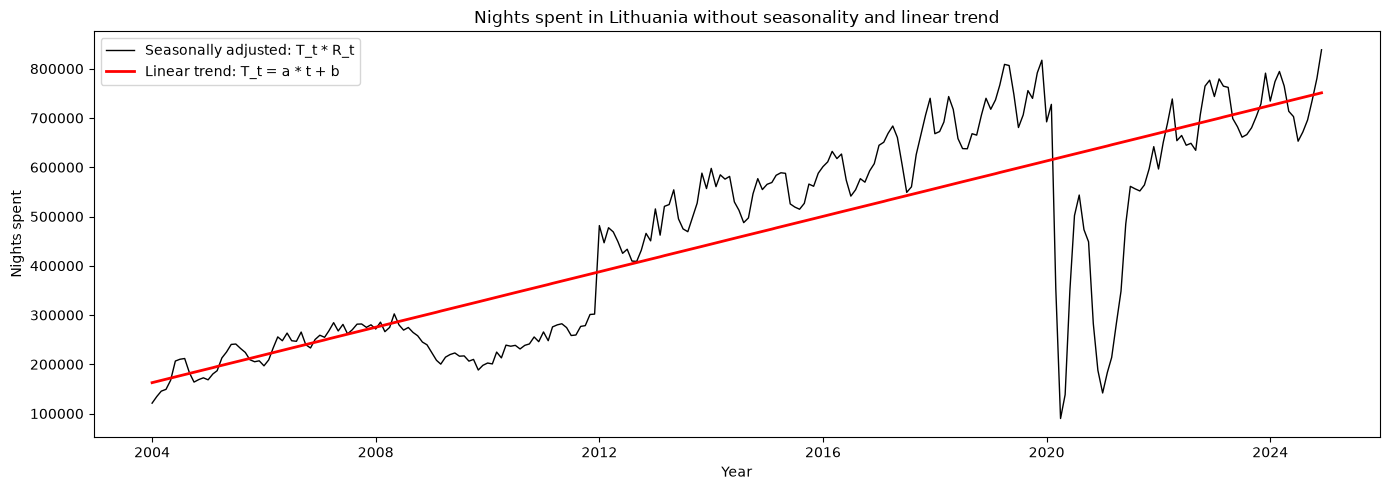

,nights,cma,seasonal_residual,seasonal,trend_residual,trend
date,,,,,,
2004-01-01,77111.0,NaN,NaN,0.636560,121137.122461,162732.575929
2004-02-01,81826.0,NaN,NaN,0.607570,134677.562883,165076.410189
2004-03-01,100774.0,NaN,NaN,0.692519,145518.107642,167420.244448
2004-04-01,111915.0,NaN,NaN,0.750300,149160.344702,169764.078708
2004-05-01,166392.0,NaN,NaN,0.993336,167508.305148,172107.912967
...,...,...,...,...,...,...
2024-08-01,1220439.0,NaN,NaN,1.817285,671572.722154,741659.638041
2024-09-01,748968.0,NaN,NaN,1.076086,696011.491519,744003.472300
2024-10-01,635245.0,NaN,NaN,0.863166,735947.819223,746347.306560


In [44]:
import numpy as np

# Linear trend: T_t = a * t + b, fitted by OLS on the seasonally adjusted series (T_t * R_t)
# t is the time index (1, 2, ..., n), one step per month
t = np.arange(1, len(df_train) + 1)
X_trend = sm.add_constant(t)
linear_trend = sm.OLS(df_train["trend_residual"], X_trend).fit()
b_hat, a_hat_trend = linear_trend.params
print(linear_trend.summary().tables[1])
print(f"\nT_t = {a_hat_trend:.2f} * t + {b_hat:.2f}   (R² = {linear_trend.rsquared:.3f})")

# Trend component T_t
df_train = df_train.assign(trend=linear_trend.predict(X_trend))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_train.index, df_train["trend_residual"], color="black", linewidth=1, label="Seasonally adjusted: T_t * R_t")
ax.plot(df_train.index, df_train["trend"], color="red", linewidth=2, label="Linear trend: T_t = a * t + b")
ax.set_title("Nights spent in Lithuania without seasonality and linear trend")
ax.set_xlabel("Year")
ax.set_ylabel("Nights spent")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

df_train

> Linear trend

What we can say about it, it's that it is clearly not perfect. $R^2 = 0.668$ is not a perfect score at all. But we can observe that the global tendancy is not too bad if we take into account the growth and the world issues than happend at random moment. A good point is that even if the global TS don't match everywhere, the last years are aligned with the trend thanks to the covid impact. This is a bit lucky result so we will try to use excponentiel smoothing method to try to compare the results.

### 1.4.2. Exponential Smoothing trend
We apply a double exponential smoothing (Brown's method, one parameter $0 < \lambda < 1$) on the seasonally adjusted series $Y'_t = T_t \cdot R_t$. The series is smoothed once, then the smoothed series is smoothed a second time.

**First smoothing:**

$$\hat{Y}_t = \lambda \, Y'_{t-1} + (1 - \lambda)\, \hat{Y}_{t-1}$$

**Second smoothing:**

$$\hat{\hat{Y}}_t = \lambda \, \hat{Y}_t + (1 - \lambda)\, \hat{\hat{Y}}_{t-1}$$

**Level and slope:**

$$b_t = 2\,\hat{Y}_t - \hat{\hat{Y}}_t \qquad a_t = \left(\hat{Y}_t - \hat{\hat{Y}}_t\right) \cdot \frac{\lambda}{1 - \lambda}$$

**Initialization:** $\hat{Y}_1 = \hat{\hat{Y}}_1 = Y'_1$

**Trend estimate on the train set:** $\hat{T}_t = b_t$

**Forecast** ($n$ = last train month, $h = 1, 2, \dots$):

$$\hat{T}_{n+h} = b_n + h \cdot a_n$$

**Choice of $\lambda$:** the fit error $\sum_t (Y'_t - b_t)^2$ keeps decreasing as $\lambda$ gets close to 1. With $\lambda \to 1$, $b_t$ copies the series and absorbs the residual $R_t$. We therefore fix $\lambda = 0.1$ to keep a smooth trend.


lambda = 0.1: last level b_n = 742458, last slope a_n = 2890 nights per month


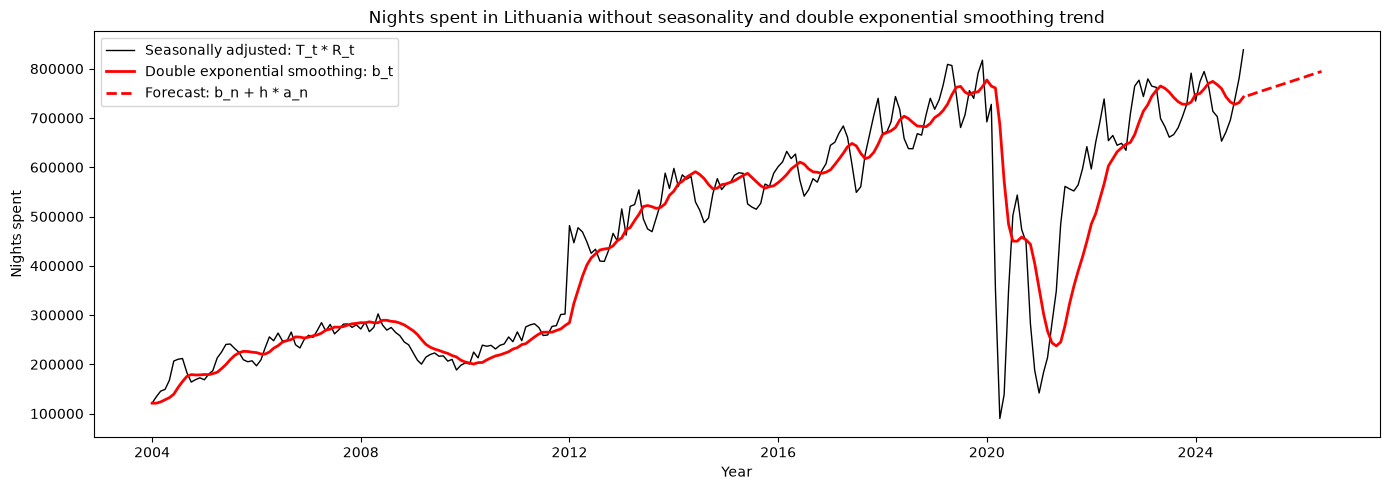

,nights,cma,seasonal_residual,seasonal,trend_residual,trend,trend_des
date,,,,,,,
2004-01-01,77111.0,NaN,NaN,0.636560,121137.122461,162732.575929,121137.122461
2004-02-01,81826.0,NaN,NaN,0.607570,134677.562883,165076.410189,121137.122461
2004-03-01,100774.0,NaN,NaN,0.692519,145518.107642,167420.244448,123709.806141
2004-04-01,111915.0,NaN,NaN,0.750300,149160.344702,169764.078708,127963.060994
2004-05-01,166392.0,NaN,NaN,0.993336,167508.305148,172107.912967,132275.772932
...,...,...,...,...,...,...,...
2024-08-01,1220439.0,NaN,NaN,1.817285,671572.722154,741659.638041,743005.365057
2024-09-01,748968.0,NaN,NaN,1.076086,696011.491519,744003.472300,732267.919341
2024-10-01,635245.0,NaN,NaN,0.863166,735947.819223,746347.306560,727607.002519


In [64]:
def brown_double_smoothing(y, lam):
    """Brown's double exponential smoothing: returns the level b_t and the slope a_t."""
    s1 = np.empty(len(y))  # first smoothing: Y^_t
    s2 = np.empty(len(y))  # second smoothing: Y^^_t
    # Initialization: Y^_1 = Y^^_1 = Y'_1
    s1[0] = s2[0] = y[0]
    for t in range(1, len(y)):
        s1[t] = lam * y[t - 1] + (1 - lam) * s1[t - 1]
        s2[t] = lam * s1[t] + (1 - lam) * s2[t - 1]
    level = 2 * s1 - s2
    slope = (s1 - s2) * lam / (1 - lam)
    return level, slope


# Seasonally adjusted series Y'_t = T_t * R_t
y_adj = df_train["trend_residual"].to_numpy()

# The SSE keeps decreasing when lambda goes to 1 (b_t copies the series and absorbs R_t),
# so we fix a small lambda to keep a smooth trend
lambda_des = 0.1
level_des, slope_des = brown_double_smoothing(y_adj, lambda_des)

# Trend component T_t: the level b_t
df_train = df_train.assign(trend_des=level_des)

# Forecast over the test horizon: T_{n+h} = b_n + h * a_n
h = np.arange(1, len(df_test) + 1)
trend_des_forecast = pd.Series(level_des[-1] + h * slope_des[-1], index=df_test.index, name="trend_des")
print(f"\nlambda = {lambda_des}: last level b_n = {level_des[-1]:.0f}, last slope a_n = {slope_des[-1]:.0f} nights per month")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_train.index, df_train["trend_residual"], color="black", linewidth=1, label="Seasonally adjusted: T_t * R_t")
ax.plot(df_train.index, df_train["trend_des"], color="red", linewidth=2, label="Double exponential smoothing: b_t")
ax.plot(trend_des_forecast.index, trend_des_forecast, color="red", linestyle="--", linewidth=2, label="Forecast: b_n + h * a_n")
ax.set_title("Nights spent in Lithuania without seasonality and double exponential smoothing trend")
ax.set_xlabel("Year")
ax.set_ylabel("Nights spent")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

df_train

> Exponential smoothing trend

This method use the past data to forecast the next one. The result is a linear trend to forecast the next values. It is difficult to know which method is the best actually so we will compare both result with errors measurement after recomposition. 

### 1.4.3. Detrend
We know have to detrend from or linear trend or from our double exponential smoothing (des). After that, we'll perform ARIMA's model to forecast both residual component (linear en des).

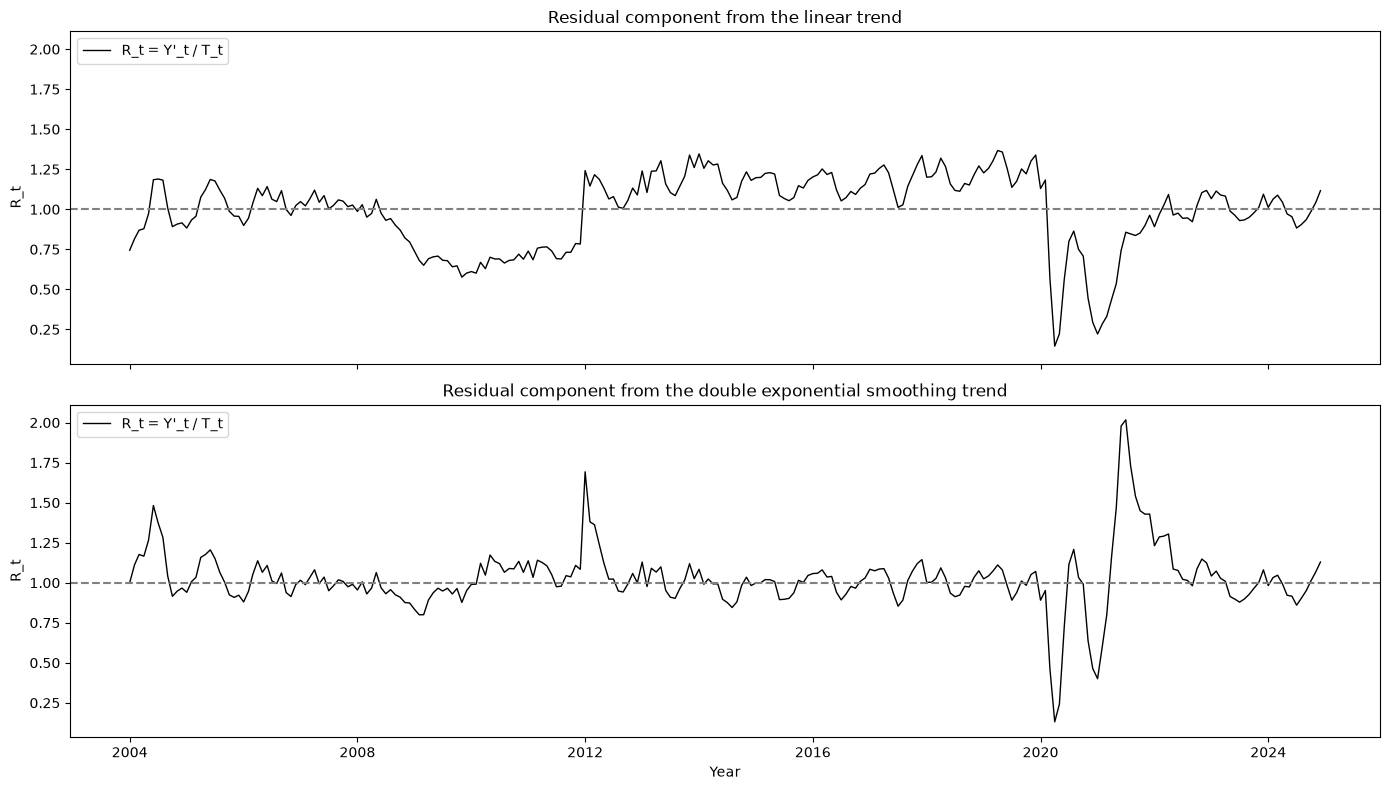

,nights,cma,seasonal_residual,seasonal,trend_residual,trend,trend_des,residual_linear,residual_des
date,,,,,,,,,
2004-01-01,77111.0,NaN,NaN,0.636560,121137.122461,162732.575929,121137.122461,0.744394,1.000000
2004-02-01,81826.0,NaN,NaN,0.607570,134677.562883,165076.410189,121137.122461,0.815850,1.111778
2004-03-01,100774.0,NaN,NaN,0.692519,145518.107642,167420.244448,123709.806141,0.869179,1.176286
2004-04-01,111915.0,NaN,NaN,0.750300,149160.344702,169764.078708,127963.060994,0.878633,1.165652
2004-05-01,166392.0,NaN,NaN,0.993336,167508.305148,172107.912967,132275.772932,0.973275,1.266357
...,...,...,...,...,...,...,...,...,...
2024-08-01,1220439.0,NaN,NaN,1.817285,671572.722154,741659.638041,743005.365057,0.905500,0.903860
2024-09-01,748968.0,NaN,NaN,1.076086,696011.491519,744003.472300,732267.919341,0.935495,0.950487
2024-10-01,635245.0,NaN,NaN,0.863166,735947.819223,746347.306560,727607.002519,0.986066,1.011463


In [65]:
# Multiplicative model: Y'_t / T_t = (T_t * R_t) / T_t = R_t
# One residual component per trend estimate (linear and double exponential smoothing)
df_train = df_train.assign(
    residual_linear=df_train["trend_residual"] / df_train["trend"],
    residual_des=df_train["trend_residual"] / df_train["trend_des"],
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, sharey=True)
residuals = [
    (axes[0], "residual_linear", "Residual component from the linear trend"),
    (axes[1], "residual_des", "Residual component from the double exponential smoothing trend"),
]
for ax, col, title in residuals:
    ax.plot(df_train.index, df_train[col], color="black", linewidth=1, label="R_t = Y'_t / T_t")
    ax.axhline(1, color="grey", linestyle="--")
    ax.set_title(title)
    ax.set_ylabel("R_t")
    ax.legend(loc="upper left")
axes[1].set_xlabel("Year")
plt.tight_layout()
plt.show()

df_train

## 1.5. Residual Forecasting

### 1.5.1. Stationarity
Before fitting an ARIMA model, the residual component $R_t$ must be stationary: constant mean, constant variance and no unit root. We check this for both residuals (`residual_linear` and `residual_des`) with two tools.

**Augmented Dickey-Fuller (ADF) test** (with a constant, number of lags $m$ chosen by AIC):

$$\Delta R_t = c + \gamma \, R_{t-1} + \sum_{i=1}^{m} \delta_i \, \Delta R_{t-i} + \varepsilon_t \qquad \text{with } \Delta R_t = R_t - R_{t-1}$$

- $H_0$: $\gamma = 0$, the series has a unit root (not stationary)
- $H_1$: $\gamma < 0$, the series is stationary

We reject $H_0$ at the 5% level if the p-value is below 0.05.

**Constant mean and variance:** like in section 1.1, we split the series into one window per year ($i = 1, \dots, 21$) and compute the mean $\bar{R}_i$ and the standard deviation $\text{Std}_i$ of each window. We then fit two OLS regressions on the year index:

$$\bar{R}_i = \alpha_1 + \beta_1 \, i + e_i \qquad \text{Std}_i = \alpha_2 + \beta_2 \, i + e_i$$

and run a t-test on $H_0$: $\beta = 0$ at 5%. If $H_0$ is not rejected, the mean (or the std) does not drift over time.

**Decision:** the series is stationary if the ADF test rejects $H_0$ **and** both t-tests do not reject $H_0$. Otherwise we difference it, $\Delta R_t = R_t - R_{t-1}$, and test again (up to $d = 2$).

In [ ]:
from statsmodels.tsa.stattools import adfuller


def stationarity_tests(series):
    """ADF test + t-tests on the slope of the yearly mean and yearly std."""
    adf_stat, adf_p, used_lag, *_ = adfuller(series, regression="c", autolag="AIC")
    # One window per calendar year, like in section 1.1
    yearly = series.groupby(series.index.year).agg(mean="mean", std="std")
    # Fit mean_i = alpha + beta * i and std_i = alpha + beta * i, then t-test on H0: beta = 0
    X_year = sm.add_constant(np.arange(len(yearly)))
    p_mean = sm.OLS(yearly["mean"], X_year).fit().pvalues.iloc[1]
    p_std = sm.OLS(yearly["std"], X_year).fit().pvalues.iloc[1]
    stationary = adf_p < alpha and p_mean >= alpha and p_std >= alpha
    return {"adf": adf_stat, "adf_p": adf_p, "used_lag": used_lag, "p_mean": p_mean, "p_std": p_std,
            "yearly": yearly, "stationary": stationary}


residual_cols = ["residual_linear", "residual_des"]
max_d = 2
# levels[col][k] is the series differenced k times; the last one is the stationary series
levels = {}
tests = {}
for col in residual_cols:
    levels[col] = [df_train[col]]
    for d in range(max_d + 1):
        result = stationarity_tests(levels[col][-1])
        print(
            f"{col}, d = {d}: ADF = {result['adf']:.3f} (p-value = {result['adf_p']:.4f}, {result['used_lag']} lags) | "
            f"slope of yearly mean: p-value = {result['p_mean']:.3f} | slope of yearly std: p-value = {result['p_std']:.3f}"
        )
        if result["stationary"] or d == max_d:
            break
        # Not stationary: difference once more, dR_t = R_t - R_{t-1}
        levels[col].append(levels[col][-1].diff().dropna())
    tests[col] = result
    verdict = "stationary" if result["stationary"] else "NOT stationary"
    print(f"-> {col} is {verdict} with d = {len(levels[col]) - 1}\n")

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)
for j, col in enumerate(residual_cols):
    yearly = tests[col]["yearly"]
    for i, stat in enumerate(["mean", "std"]):
        ax = axes[i, j]
        ax.plot(yearly.index, yearly[stat], marker="o", color="black")
        ax.axhline(yearly[stat].mean(), color="grey", linestyle="--", label=f"Average of the yearly {stat}")
        ax.set_title(f"Yearly {stat} of {col} (d = {len(levels[col]) - 1})")
        ax.legend(loc="upper left")
for ax in axes[1]:
    ax.set_xlabel("Year")
plt.tight_layout()
plt.show()

> Is $R_t$ stationary?

| Series | ADF statistic | ADF p-value | Slope of yearly mean (p-value) | Slope of yearly std (p-value) | $d$ |
|---|---|---|---|---|---|
| `residual_linear` | -3.092 | 0.027 | 0.754 | 0.232 | 0 |
| `residual_des` | -4.612 | 0.0001 | 0.926 | 0.249 | 0 |

Both residuals are **stationary without differencing** ($d = 0$): the ADF test rejects the unit root at 5%, and neither the yearly mean nor the yearly std has a significant trend. On the plots, the yearly mean stays close to 1 and the std is roughly flat. The only exceptions are 2020 and 2021, when COVID produced a large drop and a large spread. These two years are shocks, not a drift, so the slope tests do not detect them. The ADF test is less clear-cut for `residual_linear` (p-value = 0.027) than for `residual_des`, because the linear trend misses part of the long-term movement, which leaves slow waves in its residual.

### 1.5.2. PACF
The partial autocorrelation $\phi_{kk}$ at lag $k$ is the correlation between $R_t$ and $R_{t-k}$ once the effect of the intermediate lags $R_{t-1}, \dots, R_{t-k+1}$ has been removed. We compute it by OLS: $\phi_{kk}$ is the last coefficient of the AR($k$) regression

$$R_t = c + \phi_{k1} \, R_{t-1} + \phi_{k2} \, R_{t-2} + \dots + \phi_{kk} \, R_{t-k} + \varepsilon_t$$

**Significance:** under $H_0$: $\phi_{kk} = 0$, $\hat{\phi}_{kk}$ is approximately $\mathcal{N}(0, 1/n)$. Lag $k$ is significant at 5% if

$$|\hat{\phi}_{kk}| > \frac{1.96}{\sqrt{n}}$$

With $n = 252$ months, the band is $\pm 0.123$. We look at the first 24 lags (two seasonal cycles).

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import pacf

n_lags = 24  # two full seasonal cycles

significant_lags = {}
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for ax, col in zip(axes, residual_cols):
    z = levels[col][-1]  # stationary series
    # PACF computed by OLS: phi_kk is the last coefficient of the AR(k) regression
    phi_kk = pacf(z, nlags=n_lags, method="ols")
    bound = 1.96 / np.sqrt(len(z))  # 95% confidence band under H0: phi_kk = 0
    significant_lags[col] = [k for k in range(1, n_lags + 1) if abs(phi_kk[k]) > bound]
    print(f"{col}: band = +/-{bound:.3f}, significant lags = {significant_lags[col]}")

    plot_pacf(z, lags=n_lags, method="ols", ax=ax, title=f"PACF of {col}")
    ax.set_ylabel("PACF")
axes[1].set_xlabel("Lag k (months)")
plt.tight_layout()
plt.show()

> Significant lags

| Series | Significant lags $k$ |
|---|---|
| `residual_linear` | 1, 2, 4, 6, 8, 13 |
| `residual_des` | 1, 2, 3, 8, 9, 11, 13, 14, 17 |

For both residuals, lag 1 is by far the strongest ($\hat{\phi}_{11} \approx 0.92$ for linear and $0.83$ for DES): a month above its trend is usually followed by another month above it. Lag 2 is negative in both cases. The other lags are small, only just outside the band. With 24 lags tested at 5%, we expect about one lag to cross the band by chance, so some of them (like 17) may be noise. We still keep them all, following the PACF rule.

### 1.5.3. ARIMA
Since $d = 0$ for both residuals, the ARIMA($p$, $d$, 0) model reduces to an AR model on $R_t$, fitted only on a set of lags $K = \{k_1, \dots, k_p\}$:

$$R_t = c + \sum_{k \in K} \phi_k \, R_{t-k} + \varepsilon_t$$

**Estimation:** OLS regression of $R_t$ on its lagged values $R_{t-k}$, $k \in K$ (the first $\max(K)$ months are dropped because their lags are missing).

**Ljung-Box test** on the regression residuals $\hat{\varepsilon}_t$, with $\hat{\rho}_j$ the autocorrelation of $\hat{\varepsilon}_t$ at lag $j$:

$$Q(h) = n(n+2) \sum_{j=1}^{h} \frac{\hat{\rho}_j^2}{n - j} \sim \chi^2(h - p) \text{ under } H_0$$

- $H_0$: no autocorrelation up to lag $h$, the residuals are white noise
- $H_1$: at least one $\rho_j \neq 0$

We use $h = 12$ and $h = 24$, and remove the $p$ estimated coefficients from the degrees of freedom. We reject $H_0$ at 5% if the p-value is below 0.05. The residuals are white noise if $H_0$ is not rejected at both $h$.

**Lag selection (Box-Jenkins iteration):**
1. Start with $K$ = the significant lags of the PACF (section 1.5.2), fit the model and run the Ljung-Box test.
2. If $H_0$ is rejected, some structure is left in $\hat{\varepsilon}_t$. The candidates are the lags $j \notin K$ where the residual ACF is significant: $|\hat{\rho}_j| > 1.96 / \sqrt{n}$.
3. Refit the model once with each candidate added to $K$, and keep the candidate that gives the smallest $Q(24)$, i.e. the one that removes the most autocorrelation.
4. Repeat from step 1 until $H_0$ is not rejected, or until no candidate is left.

**Recursive forecast** over the test period ($n$ = last train month, $h = 1, \dots, 18$):

$$\hat{R}_{n+h} = \hat{c} + \sum_{k \in K} \hat{\phi}_k \, \tilde{R}_{n+h-k} \qquad \text{with } \tilde{R}_s = \begin{cases} R_s & \text{if } s \le n \text{ (observed)} \\ \hat{R}_s & \text{if } s > n \text{ (already forecast)} \end{cases}$$

The future errors $\varepsilon_{n+h}$ are replaced by their expected value, 0. This is the best guess only if $\varepsilon_t$ is white noise, which is why the Ljung-Box test must pass before forecasting.

If the series had been differenced, we would forecast $\Delta R_t$ and integrate back with $\hat{R}_{n+h} = \hat{R}_{n+h-1} + \widehat{\Delta R}_{n+h}$. This is not needed here, because $d = 0$.

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf


def fit_ar(z, lags):
    """OLS regression z_t = c + sum_k phi_k * z_{t-k} + e_t, on the given lags only."""
    X_lags = pd.concat({f"lag_{k}": z.shift(k) for k in lags}, axis=1)
    data = pd.concat([z.rename("z"), X_lags], axis=1).dropna()
    return sm.OLS(data["z"], sm.add_constant(data[X_lags.columns])).fit()


def ljung_box(resid, n_params):
    """Ljung-Box test at h = 12 and 24. Q follows a chi2(h - p) under H0, p = number of AR coefficients."""
    return acorr_ljungbox(resid, lags=[12, 24], model_df=n_params)


ar_models = {}
ar_lags = {}
residual_forecast = pd.DataFrame(index=df_test.index)
for col in residual_cols:
    z = levels[col][-1]
    # Step 1: start from the significant PACF lags
    lags = list(significant_lags[col])
    step = 1
    while True:
        ar = fit_ar(z, lags)
        lb = ljung_box(ar.resid, len(lags))
        white_noise = (lb["lb_pvalue"] >= alpha).all()
        print(f"===== {col}, step {step}: lags {lags} =====")
        print(ar.summary().tables[1])
        print(f"R2 = {ar.rsquared:.3f}")
        print(lb)
        if white_noise:
            print("H0 not rejected: the residuals are white noise\n")
            break
        print("H0 rejected: the residuals are NOT white noise")

        # Step 2: the candidates are the lags where the residual ACF is significant
        rho = acf(ar.resid, nlags=n_lags)
        bound = 1.96 / np.sqrt(len(ar.resid))
        candidates = [k for k in range(1, n_lags + 1) if abs(rho[k]) > bound and k not in lags]
        if not candidates:
            print("No significant lag left in the residual ACF: we stop and keep this model\n")
            break
        # Refit with each candidate and keep the one that removes the most autocorrelation (smallest Q(24))
        q24 = {k: ljung_box(fit_ar(z, sorted(lags + [k])).resid, len(lags) + 1)["lb_stat"].iloc[-1] for k in candidates}
        new_lag = min(q24, key=q24.get)
        print(f"Significant residual ACF at lags {candidates}, Q(24) after adding each: "
              f"{ {k: round(q, 1) for k, q in q24.items()} }")
        print(f"-> add lag {new_lag} and refit\n")
        lags = sorted(lags + [new_lag])
        step += 1
    ar_models[col] = ar
    ar_lags[col] = lags

    # Recursive forecast: each prediction is fed back as a lagged value for the next months
    history = list(z.to_numpy())
    for _ in range(len(df_test)):
        history.append(ar.params["const"] + sum(ar.params[f"lag_{k}"] * history[-k] for k in lags))
    forecast = pd.Series(history[-len(df_test):], index=df_test.index)

    # If the series was differenced, integrate back: R_{n+h} = R_{n+h-1} + dR_{n+h}
    for level in reversed(levels[col][:-1]):
        forecast = level.iloc[-1] + forecast.cumsum()
    residual_forecast[col] = forecast

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, sharey=True)
for ax, col in zip(axes, residual_cols):
    fitted = ar_models[col].fittedvalues
    ax.plot(df_train.index, df_train[col], color="black", linewidth=1, label="R_t (train)")
    if len(levels[col]) == 1:
        ax.plot(fitted.index, fitted, color="blue", linewidth=1, alpha=0.7, label="In-sample fit")
    ax.plot(residual_forecast.index, residual_forecast[col], color="red", linewidth=2, label="Recursive forecast")
    ax.axhline(1, color="grey", linestyle="--")
    ax.set_title(f"{col}: AR model on lags {ar_lags[col]}")
    ax.set_ylabel("R_t")
    ax.legend(loc="upper left")
axes[1].set_xlabel("Year")
plt.tight_layout()
plt.show()

residual_forecast

> ARIMA results

| Series | Step | Lags $K$ | $R^2$ | Ljung-Box $h = 12$ (p-value) | Ljung-Box $h = 24$ (p-value) | White noise? |
|---|---|---|---|---|---|---|
| `residual_linear` | 1 (PACF) | 1, 2, 4, 6, 8, 13 | 0.879 | 1.2e-05 | 7.8e-07 | No |
| `residual_linear` | 2 (+ lag 3) | 1, 2, 3, 4, 6, 8, 13 | 0.883 | 0.009 | 0.032 | No |
| `residual_linear` | 3 (+ lag 12) | 1, 2, 3, 4, 6, 8, 12, 13 | 0.887 | 0.122 | 0.257 | **Yes** |
| `residual_des` | 1 (PACF) | 1, 2, 3, 8, 9, 11, 13, 14, 17 | 0.767 | 0.002 | 0.007 | No |
| `residual_des` | 2 (+ lag 12) | 1, 2, 3, 8, 9, 11, 12, 13, 14, 17 | 0.780 | 0.321 | 0.230 | **Yes** |

With only the PACF lags, **the Ljung-Box test rejects white noise for both models**: some autocorrelation is left in the regression residuals, so part of $R_t$ could still be predicted from its past. The residual ACF shows where it is:
- **Lag 12** is added to both models. This is a seasonal leftover: the seasonal coefficients are fixed over 21 years, but the seasonal profile slightly changed over time, for example in November-December 2019 (see the Buys-Ballot table in 1.3.2). With lag 13 already in the model, the pair $\hat{\phi}_{12} R_{t-12} + \hat{\phi}_{13} R_{t-13}$ (0.19 and -0.25 for linear, 0.32 and -0.42 for DES) links each month to the same month one year before.
- **Lag 3** is also needed for `residual_linear`. Its residual keeps slow waves, because the straight line misses the long swings of the series (2009 crisis, 2012 jump, COVID).

After the iteration, **both residuals are white noise at 5%** and the AR models can be used to forecast. Note that the linear model needs one more step and one more lag than the DES model: the DES trend follows the series more closely, so it leaves a cleaner residual.

Both forecasts start from the last train value ($R_t \approx 1.12$ in December 2024). They fall to about 0.97-0.99 in spring 2025, go back up to about 1.06-1.08 in autumn 2025, and then settle down, reaching about 1.00-1.03 in June 2026. The oscillation comes from the lags 12-13 and gets smaller at each cycle, as $\hat{R}_{n+h}$ converges to the long-term mean of $R_t$.

## 1.6. Forecast and Recomposition
We now have a forecast for each component, so we can recompose the series with the multiplicative model $Y_t = T_t \cdot S_t \cdot R_t$. We do it twice, once with the linear trend and once with the double exponential smoothing (DES) trend.

**Trend forecast** ($n$ = last train month, $h = 1, \dots, 18$):
- Linear: $\hat{T}_{n+h} = \hat{a} \cdot (n + h) + \hat{b}$
- DES: $\hat{T}_{n+h} = b_n + h \cdot a_n$ (already computed in section 1.4.2)

**Seasonal forecast:** $\hat{S}_{n+h} = S_m$, the seasonal coefficient of the calendar month $m$ of $n + h$ (section 1.3.2).

**Residual forecast:** $\hat{R}_{n+h}$, the recursive AR forecast of section 1.5.3 (one per trend).

**Recomposition:**
- On the train set (in-sample fit): $\hat{Y}_t = T_t \cdot S_t \cdot \hat{R}_t$, with $\hat{R}_t$ the fitted values of the AR model. The first $\max(K) = 17$ months (13 for linear) have no fitted value because their lags are missing.
- On the test set (forecast of January 2025 to June 2026): $\hat{Y}_{n+h} = \hat{T}_{n+h} \cdot \hat{S}_{n+h} \cdot \hat{R}_{n+h}$

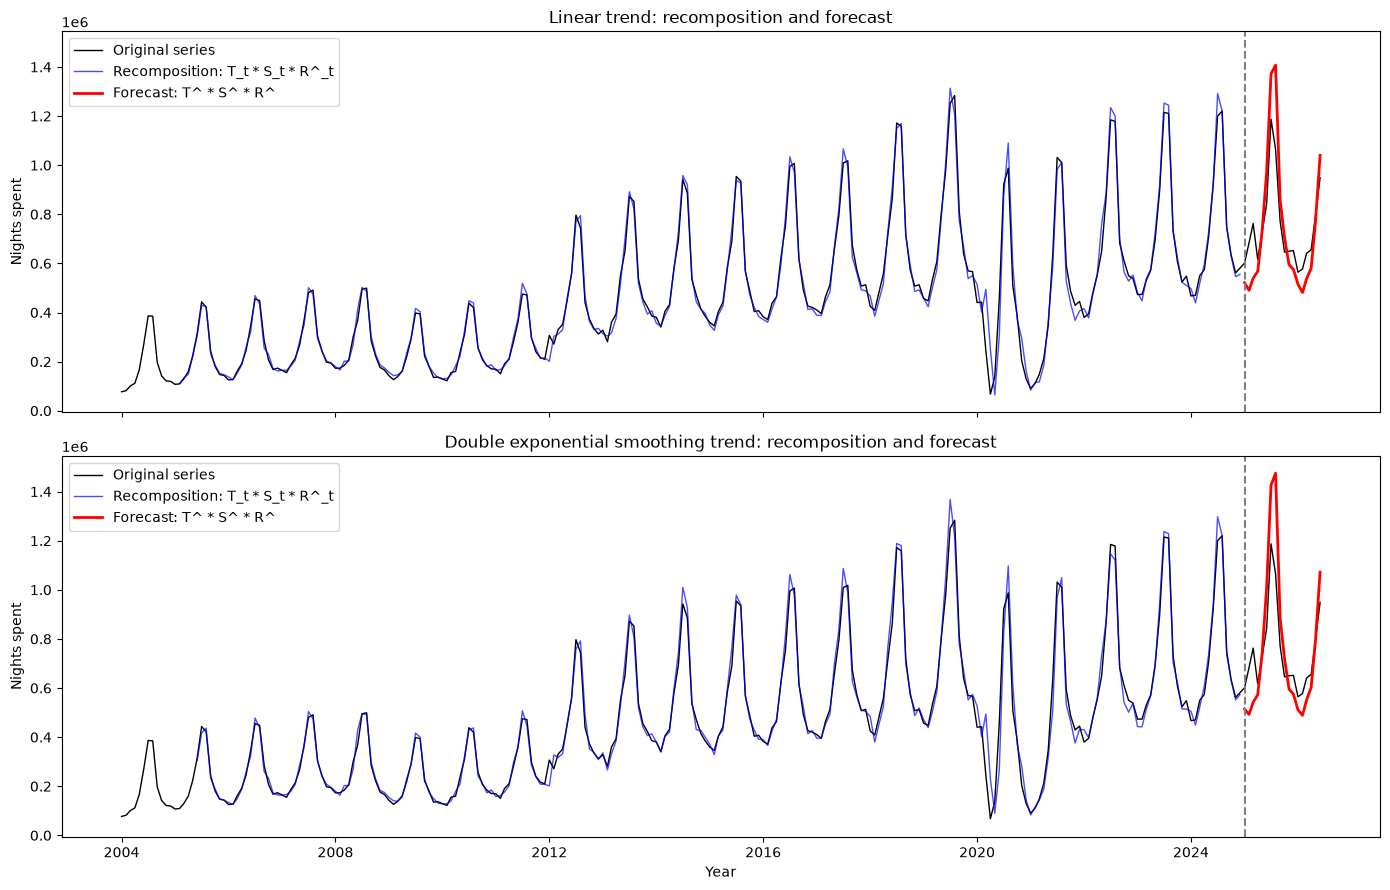

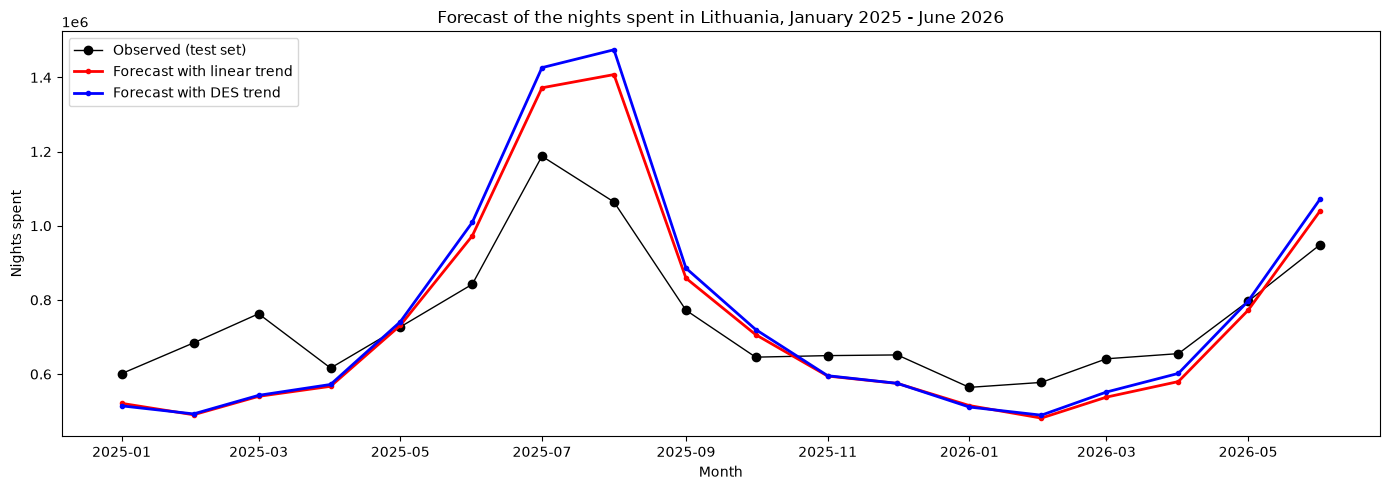

,nights,trend,trend_des,seasonal,residual_linear,residual_des,forecast_linear,forecast_des
date,,,,,,,,
2025-01-01,601162.0,753378.809338,745348.849174,0.636560,1.086812,1.084143,5.212031e+05,5.143813e+05
2025-02-01,684134.0,755722.643598,748239.212920,0.607570,1.067868,1.083693,4.903158e+05,4.926549e+05
2025-03-01,762656.0,758066.477857,751129.576666,0.692519,1.028558,1.043321,5.399672e+05,5.427055e+05
2025-04-01,616298.0,760410.312117,754019.940412,0.750300,0.993991,1.011131,5.671077e+05,5.720384e+05
2025-05-01,727097.0,762754.146377,756910.304158,0.993336,0.965160,0.985534,7.312738e+05,7.409899e+05
2025-06-01,842228.0,765097.980636,759800.667904,1.312979,0.968322,1.011538,9.727350e+05,1.009113e+06
2025-07-01,1187481.0,767441.814896,762691.031650,1.837763,0.972757,1.017599,1.371953e+06,1.426313e+06
2025-08-01,1064118.0,769785.649155,765581.395396,1.817285,1.006224,1.059871,1.407627e+06,1.474577e+06
2025-09-01,772257.0,772129.483415,768471.759142,1.076086,1.033460,1.070959,8.586784e+05,8.856201e+05


In [77]:
# Linear trend forecast: extend T_t = a * t + b over the test horizon (t = n+1, ..., n+h)
t_test = np.arange(len(df_train) + 1, len(df_train) + len(df_test) + 1)
trend_linear_forecast = pd.Series(linear_trend.predict(sm.add_constant(t_test)), index=df_test.index)

# Seasonal forecast: each future month gets the coefficient of its calendar month
seasonal_forecast = pd.Series(df_test.index.month.map(seasonal_coef).to_numpy(), index=df_test.index)

# In-sample recomposition on the train set: Y^_t = T_t * S_t * R^_t, with R^_t the AR fitted values
# (NaN for the first max(K) months, whose lags are missing)
df_train = df_train.assign(
    recomposed_linear=df_train["trend"] * df_train["seasonal"] * ar_models["residual_linear"].fittedvalues,
    recomposed_des=df_train["trend_des"] * df_train["seasonal"] * ar_models["residual_des"].fittedvalues,
)

# Forecast over the test period: Y^_{n+h} = T^_{n+h} * S^_{n+h} * R^_{n+h}
df_forecast = pd.DataFrame(
    {
        "nights": df_test["nights"],
        "trend": trend_linear_forecast,
        "trend_des": trend_des_forecast,
        "seasonal": seasonal_forecast,
        "residual_linear": residual_forecast["residual_linear"],
        "residual_des": residual_forecast["residual_des"],
    }
)
df_forecast = df_forecast.assign(
    forecast_linear=df_forecast["trend"] * df_forecast["seasonal"] * df_forecast["residual_linear"],
    forecast_des=df_forecast["trend_des"] * df_forecast["seasonal"] * df_forecast["residual_des"],
)

# Full period: recomposition on the train set and forecast on the test set
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True, sharey=True)
methods = [
    (axes[0], "recomposed_linear", "forecast_linear", "Linear trend"),
    (axes[1], "recomposed_des", "forecast_des", "Double exponential smoothing trend"),
]
for ax, recomposed_col, forecast_col, name in methods:
    ax.plot(df.index, df["nights"], color="black", linewidth=1, label="Original series")
    ax.plot(df_train.index, df_train[recomposed_col], color="blue", linewidth=1, alpha=0.7, label="Recomposition: T_t * S_t * R^_t")
    ax.plot(df_forecast.index, df_forecast[forecast_col], color="red", linewidth=2, label="Forecast: T^ * S^ * R^")
    ax.axvline(df_test.index[0], color="grey", linestyle="--")
    ax.set_title(f"{name}: recomposition and forecast")
    ax.set_ylabel("Nights spent")
    ax.legend(loc="upper left")
axes[1].set_xlabel("Year")
plt.tight_layout()
plt.show()

# Zoom on the test period: both forecasts against the observed values
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_forecast.index, df_forecast["nights"], color="black", marker="o", linewidth=1, label="Observed (test set)")
ax.plot(df_forecast.index, df_forecast["forecast_linear"], color="red", marker=".", linewidth=2, label="Forecast with linear trend")
ax.plot(df_forecast.index, df_forecast["forecast_des"], color="blue", marker=".", linewidth=2, label="Forecast with DES trend")
ax.set_title("Forecast of the nights spent in Lithuania, January 2025 - June 2026")
ax.set_xlabel("Month")
ax.set_ylabel("Nights spent")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

df_forecast

> Forecast and recomposition

On the train set, both recompositions follow the original series very closely: the trend and the seasonality give the shape, and the AR model on $R_t$ corrects most of the deviations, including the COVID drop.

On the test set, both forecasts are very close to each other. The DES forecast is a bit higher because its trend starts lower (745 000 vs 753 000 nights in January 2025) but grows faster. Over 2025, the observed total is 9.20 million nights, against 9.34 million for the linear forecast (+1.4%) and 9.55 million for the DES forecast (+3.7%).

The yearly level is therefore well forecast, but the seasonal shape is not. Both models **underestimate the winter and spring** (-28% to -29% in February and March 2025) and **overestimate the summer** (+32% to +39% in August 2025). In 2025, the seasonal profile was flatter than the average profile of 2004-2024: the peak in summer was lower and the low season was higher. Our seasonal coefficients are fixed over 21 years, so they cannot follow this change. The same pattern appears in the first half of 2026, but with smaller errors.

We will measure these errors precisely in the next section.

## 1.7. Errors measurement
We compare the forecast $\hat{Y}_t$ with the observed values $Y_t$ of the test set, for both trends. With $e_t = Y_t - \hat{Y}_t$ and $N$ the number of forecast months:

| Metric | Formula | Meaning |
|---|---|---|
| ME (Mean Error) | $\frac{1}{N} \sum_t e_t$ | Bias: $> 0$ if the forecast is too low on average, $< 0$ if too high |
| MAE (Mean Absolute Error) | $\frac{1}{N} \sum_t \lvert e_t \rvert$ | Average size of the error, in nights |
| RMSE (Root Mean Squared Error) | $\sqrt{\frac{1}{N} \sum_t e_t^2}$ | Like the MAE, but large errors weigh more |
| MAPE (Mean Absolute Percentage Error) | $\frac{100}{N} \sum_t \frac{\lvert e_t \rvert}{Y_t}$ | Average error in % of the observed value |
| sMAPE (symmetric MAPE) | $\frac{100}{N} \sum_t \frac{2 \lvert e_t \rvert}{\lvert Y_t \rvert + \lvert \hat{Y}_t \rvert}$ | Like the MAPE, but over- and under-forecasts are penalized the same way |

We compute them on the full test set (18 months), then on the complete year 2025 (12 months) and on the half year 2026 (6 months) separately.

ME       MAE      RMSE  MAPE (%)  \
Period             Method                                                
2025-01 -> 2026-06 Linear trend   6933.9  107032.1  133758.0      13.8   
                   DES trend    -10210.4  116606.4  151275.6      14.7   
2025               Linear trend -11020.9  123944.9  154146.3      15.3   
                   DES trend    -28728.5  140938.0  176849.8      17.1   
2026-01 -> 2026-06 Linear trend  42843.5   73206.3   78431.4      10.9   
                   DES trend     26825.9   67943.3   78110.1      10.0   

                                 sMAPE (%)  
Period             Method                   
2025-01 -> 2026-06 Linear trend       14.3  
                   DES trend          14.9  
2025               Linear trend       15.7  
                   DES trend          17.1  
2026-01 -> 2026-06 Linear trend       11.5  
                   DES trend          10.4

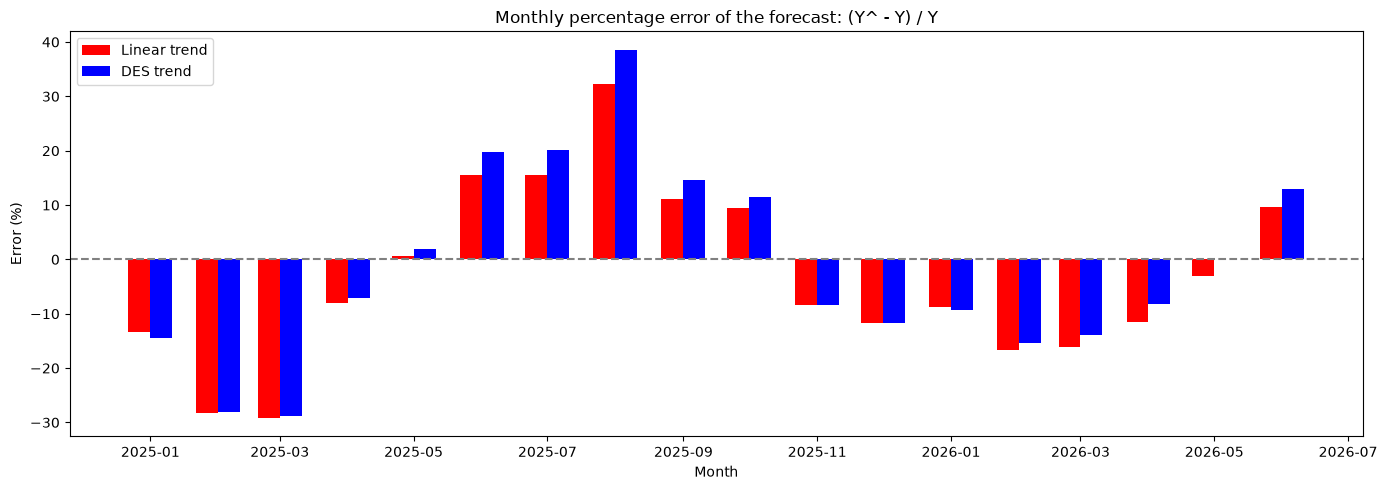

In [78]:
def error_metrics(y, y_hat):
    """ME, MAE, RMSE, MAPE and sMAPE between the observed values y and the forecast y_hat."""
    e = y - y_hat
    return {
        "ME": e.mean(),
        "MAE": e.abs().mean(),
        "RMSE": np.sqrt((e**2).mean()),
        "MAPE (%)": 100 * (e.abs() / y).mean(),
        "sMAPE (%)": 100 * (2 * e.abs() / (y.abs() + y_hat.abs())).mean(),
    }


forecast_cols = {"Linear trend": "forecast_linear", "DES trend": "forecast_des"}
# Full test set, then the complete year 2025 and the half year 2026 separately
periods = {
    "2025-01 -> 2026-06": df_forecast,
    "2025": df_forecast.loc["2025"],
    "2026-01 -> 2026-06": df_forecast.loc["2026"],
}
errors = pd.DataFrame(
    {
        (period, method): error_metrics(data["nights"], data[col])
        for period, data in periods.items()
        for method, col in forecast_cols.items()
    }
).T
errors.index.names = ["Period", "Method"]
display(errors.round(1))

# Monthly percentage error (y_hat - y) / y, to see where the forecasts miss
fig, ax = plt.subplots(figsize=(14, 5))
width = 10  # bar width, in days
for shift, (method, col), color in zip([-5, 5], forecast_cols.items(), ["red", "blue"]):
    pct_error = 100 * (df_forecast[col] - df_forecast["nights"]) / df_forecast["nights"]
    ax.bar(df_forecast.index + pd.Timedelta(days=shift), pct_error, width=width, color=color, label=method)
ax.axhline(0, color="grey", linestyle="--")
ax.set_title("Monthly percentage error of the forecast: (Y^ - Y) / Y")
ax.set_xlabel("Month")
ax.set_ylabel("Error (%)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

> Errors measurement

Over the full test set, the **linear trend gives the best forecast** on every metric, with a MAPE of 13.8% against 14.7% for the DES trend. The difference comes from 2025: the DES trend grows faster, so it overestimates the summer peak even more (see section 1.6). On the first half of 2026, the DES trend is slightly better, but this period has only 6 months and does not contain the summer peak.

The bias (ME) is small compared with the MAE for both trends: the forecasts are not much too high or too low on average, they miss the **shape** of the year. The errors are large in both directions: too low in winter and spring, too high in summer (see the bar plot). This confirms what we saw in section 1.6: the 2025 seasonal profile is flatter than our fixed seasonal coefficients, which are an average over 2004-2024. The RMSE is clearly larger than the MAE in 2025 because of a few large summer errors (up to +32% for linear and +39% for DES in August 2025).

The errors are smaller in 2026 (MAPE of about 10-11%) because the first half of the year has no summer peak. They cannot be compared directly with the 2025 values.

# 2. Facebook Prophet
Prophet is a forecasting library developed by Meta. Like the ETS decomposition, it splits the series into a trend, a seasonality and special events, but it estimates all of them at once in a single model, fitted by Bayesian optimization (Stan). With a multiplicative seasonality, the model is:

$$y(t) = g(t) \cdot \left(1 + s(t) + h(t)\right) + \varepsilon_t$$

**Trend** $g(t)$: piecewise linear, with changepoints $s_j$ where the slope can change.

$$g(t) = \left(k + \mathbf{a}(t)^\top \boldsymbol{\delta}\right) t + \left(m + \mathbf{a}(t)^\top \boldsymbol{\gamma}\right) \qquad a_j(t) = \begin{cases} 1 & \text{if } t \ge s_j \ 0 & \text{otherwise} \end{cases}$$

$k$ is the initial slope, $\delta_j$ the slope change at changepoint $s_j$, and $\gamma_j$ keeps the trend continuous. The $\delta_j$ follow a Laplace prior $\text{Laplace}(0, \tau)$, where $\tau$ is `changepoint_prior_scale`: a small $\tau$ gives a smooth trend, a large one lets the trend follow the series.

**Yearly seasonality** $s(t)$: Fourier series with period $P = 365.25$ days and order $N$:

$$s(t) = \sum_{n=1}^{N} \left( a_n \cos\frac{2\pi n t}{P} + b_n \sin\frac{2\pi n t}{P} \right)$$

**Events** $h(t)$: an extra effect on chosen dates. We use it for the COVID months (2020-2021), so this shock is not absorbed by the trend or the seasonality.

**Forecast:** $g$, $s$ and $h$ are extended over the test period, 2025-01 to 2026-06. The trend keeps the last slope, and the uncertainty interval comes from simulated future changepoints.

## 2.1. Forecasting
All the parameters are defined in the next cell, so they are easy to change. The default values are the Prophet defaults, except:
- `SEASONALITY_MODE = "multiplicative"`, because section 1.1 showed that the series is multiplicative;
- no weekly or daily seasonality, because the data is monthly;
- `USE_COVID = True`, to model the COVID months (March 2020 to May 2021) as an event.

The model is fitted on the train set only (2004-2024), like in section 1.

In [ ]:
# Prophet parameters: change them and re-run the next cells to see their effect
SEASONALITY_MODE = "multiplicative"  # "multiplicative" (model found in 1.1) or "additive"
GROWTH = "linear"  # "linear" or "flat"
YEARLY_FOURIER_ORDER = 10  # number of Fourier terms of the yearly seasonality (more = more flexible shape)
N_CHANGEPOINTS = 25  # number of potential trend changepoints
CHANGEPOINT_RANGE = 0.8  # share of the train set where changepoints can be placed
CHANGEPOINT_PRIOR_SCALE = 0.05  # trend flexibility (higher = the trend follows the series more closely)
SEASONALITY_PRIOR_SCALE = 10.0  # seasonality flexibility (higher = larger seasonal effects allowed)
USE_COVID = True  # model the COVID months as a special event, so they do not distort the trend
COVID_START, COVID_END = "2020-03-01", "2021-05-01"  # months treated as the COVID event
INTERVAL_WIDTH = 0.95  # width of the uncertainty interval

In [ ]:
import logging

from prophet import Prophet

# Hide the optimizer logs of cmdstanpy
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)

# Prophet expects two columns: ds (date) and y (value)
prophet_train = df_train["nights"].reset_index().rename(columns={"date": "ds", "nights": "y"})

# COVID event: one "holiday" per month, all sharing the same effect
covid = None
if USE_COVID:
    covid = pd.DataFrame(
        {"holiday": "covid", "ds": pd.date_range(COVID_START, COVID_END, freq="MS"), "lower_window": 0, "upper_window": 0}
    )

prophet_model = Prophet(
    growth=GROWTH,
    seasonality_mode=SEASONALITY_MODE,
    yearly_seasonality=YEARLY_FOURIER_ORDER,
    weekly_seasonality=False,  # monthly data: no weekly or daily cycle
    daily_seasonality=False,
    n_changepoints=N_CHANGEPOINTS,
    changepoint_range=CHANGEPOINT_RANGE,
    changepoint_prior_scale=CHANGEPOINT_PRIOR_SCALE,
    seasonality_prior_scale=SEASONALITY_PRIOR_SCALE,
    holidays=covid,
    interval_width=INTERVAL_WIDTH,
)
prophet_model.fit(prophet_train)

# Forecast the train months (in-sample fit) and the test months, one step per month
future = prophet_model.make_future_dataframe(periods=len(df_test), freq="MS")
prophet_pred = prophet_model.predict(future).set_index("ds")

# Keep the test period next to the observed values
prophet_forecast = pd.DataFrame(
    {
        "nights": df_test["nights"],
        "forecast_prophet": prophet_pred.loc[df_test.index, "yhat"],
        "lower": prophet_pred.loc[df_test.index, "yhat_lower"],
        "upper": prophet_pred.loc[df_test.index, "yhat_upper"],
    }
)

# Full period: in-sample fit, forecast and uncertainty interval
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
ax = axes[0]
ax.plot(df.index, df["nights"], color="black", linewidth=1, label="Original series")
ax.plot(prophet_pred.index, prophet_pred["yhat"], color="green", linewidth=1.5, label="Prophet: fit and forecast")
ax.fill_between(prophet_pred.index, prophet_pred["yhat_lower"], prophet_pred["yhat_upper"], color="green", alpha=0.2,
                label=f"{INTERVAL_WIDTH:.0%} uncertainty interval")
ax.axvline(df_test.index[0], color="grey", linestyle="--")
ax.set_title("Prophet: fit on the train set and forecast on the test set")
ax.set_xlabel("Year")
ax.set_ylabel("Nights spent")
ax.legend(loc="upper left")

# Zoom on the test period, with the ETS + ARIMA forecast (linear trend) of section 1.6 for comparison
ax = axes[1]
ax.plot(prophet_forecast.index, prophet_forecast["nights"], color="black", marker="o", linewidth=1, label="Observed (test set)")
ax.plot(prophet_forecast.index, prophet_forecast["forecast_prophet"], color="green", marker=".", linewidth=2, label="Prophet forecast")
ax.fill_between(prophet_forecast.index, prophet_forecast["lower"], prophet_forecast["upper"], color="green", alpha=0.2)
ax.plot(df_forecast.index, df_forecast["forecast_linear"], color="red", linestyle="--", linewidth=1, label="ETS + ARIMA forecast (linear trend)")
ax.set_title("Forecast of the nights spent in Lithuania, January 2025 - June 2026")
ax.set_xlabel("Month")
ax.set_ylabel("Nights spent")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

# Components found by Prophet: trend, yearly seasonality and COVID effect
prophet_model.plot_components(prophet_pred.reset_index())
plt.show()

prophet_forecast

> Prophet forecast

On the train set, Prophet follows the series well, including the COVID drop thanks to the COVID event. The components plot shows a trend that grows until 2019, then almost stops growing after COVID (about 699 000 nights per month in December 2024 and January 2025). The yearly seasonality has the expected shape, with a peak in July-August and a low in January-February.

On the test set, the Prophet forecast follows the seasonal shape well in summer: July 2025 is close to the observed value (1.21 million vs 1.19 million). But its trend is too low, so **it underestimates almost every month outside the summer**, especially in winter (-25% in January 2025, -35% in February 2025). Most of the observed values of the low season are above the upper bound of the 95% interval.

## 2.2. Errors measurements
We use the same metrics (ME, MAE, RMSE, MAPE, sMAPE) and the same periods as in section 1.7, so that we can compare Prophet with the ETS + ARIMA forecasts.

In [ ]:
# Same metrics and periods as in section 1.7 (function error_metrics)
prophet_periods = {
    "2025-01 -> 2026-06": prophet_forecast,
    "2025": prophet_forecast.loc["2025"],
    "2026-01 -> 2026-06": prophet_forecast.loc["2026"],
}
prophet_errors = pd.DataFrame(
    {(period, "Prophet"): error_metrics(data["nights"], data["forecast_prophet"]) for period, data in prophet_periods.items()}
).T
prophet_errors.index.names = ["Period", "Method"]

# Comparison with the ETS + ARIMA forecasts of section 1.7
all_errors = pd.concat([errors, prophet_errors]).sort_index(level="Period", sort_remaining=False)
all_errors = all_errors.loc[list(prophet_periods)]
display(all_errors.round(1))

# Monthly percentage error (y_hat - y) / y of Prophet and of the ETS + ARIMA forecast (linear trend)
fig, ax = plt.subplots(figsize=(14, 5))
series = [
    ("Prophet", prophet_forecast["forecast_prophet"], "green"),
    ("ETS + ARIMA (linear trend)", df_forecast["forecast_linear"], "red"),
]
for shift, (name, y_hat, color) in zip([-5, 5], series):
    pct_error = 100 * (y_hat - df_test["nights"]) / df_test["nights"]
    ax.bar(df_test.index + pd.Timedelta(days=shift), pct_error, width=10, color=color, label=name)
ax.axhline(0, color="grey", linestyle="--")
ax.set_title("Monthly percentage error of the forecast: (Y^ - Y) / Y")
ax.set_xlabel("Month")
ax.set_ylabel("Error (%)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

> Errors measurement

With its default parameters, **Prophet is not clearly better than the ETS + ARIMA approach**. Over the full test set, it has the smallest MAE and RMSE, because it makes fewer large errors in summer. But it has the worst sMAPE and a large bias (ME ≈ +80 000 nights: the forecast is too low on average), because its trend is too flat after COVID. The MAPE and the sMAPE give more weight to the low season, where Prophet misses the most. On the first half of 2026, which has no summer peak, Prophet is clearly the worst method (MAPE of 15.4% vs 10-11%).

The two methods make different errors: ETS + ARIMA gets the level of the year right but gets the seasonal shape wrong, while Prophet gets the summer shape right but is too low.

> Playing with the parameters

Some tests with one parameter changed at a time (MAPE on the full test set):

| Change | MAPE (%) |
|---|---|
| Default parameters | 14.8 |
| `USE_COVID = False` | 17.6 |
| `CHANGEPOINT_RANGE = 0.95` | 14.7 |
| `YEARLY_FOURIER_ORDER = 5` | 14.6 |
| `CHANGEPOINT_PRIOR_SCALE = 0.5` | 12.0 |

- Modeling COVID as an event is important: without it, the drop pulls the trend down and the error grows.
- A more flexible trend (`CHANGEPOINT_PRIOR_SCALE = 0.5`) catches the recovery after COVID and gives the best result of all methods.

However, we chose this value by looking at the test set, so the comparison would not be fair. To tune it properly, we would have to use a validation period inside the train set (for example 2023-2024).

# 3. Conclusion
In this project, we forecast the number of nights spent in tourist accommodation in Lithuania for 2025 and the first half of 2026, using two different approaches.

**ETS + ARIMA: a step-by-step method.** We took the series apart by hand: first the seasonality (the summer peak and the winter low), then the long-term trend, and finally what was left (the residual). Each part was forecast on its own, then the three parts were multiplied back together. We tried two ways to draw the trend:
- **Linear trend:** a straight line through the whole history. It is simple, and it happened to end at the right level after COVID.
- **Exponential smoothing trend (DES):** a trend that gives more weight to recent years. It follows the series more closely, but it extended the recent fast growth too far into the future.

This approach takes more work, but every step can be checked and explained with a statistical test. It gave the best result overall, with the linear trend (about 14% average error).

**Facebook Prophet: an automated method.** Prophet finds the trend, the seasonality and special events (here, COVID) on its own and fits them all at once. It only takes a few lines of code and a few settings. It forecast the summer peak well, but its trend stayed almost flat after COVID, so it forecast too low for most of the year. With its default settings, its average error is close to the ETS + ARIMA methods (about 15%). With a more flexible trend, it becomes the best method, but this setting has to be chosen carefully, without looking at the test set.

**What we learned:**
- No method is clearly better: the errors of all three are close, between 14% and 15% on average.
- The main difficulty is not the method but the data. COVID broke the series in 2020-2021, and in 2025 the tourism season became less concentrated in summer than in the past. A model that learns from the past cannot fully anticipate this kind of change.
- ETS + ARIMA is better to **understand** the series, because we see and control each component. Prophet is better to **get a forecast quickly**, and it is easy to adjust, but it works more like a black box.

# AI-usage policy
Claude Opus 5.5 has been used for this project.

> Help me to find a dataset that fit the needs. I would like a dataset based on the population. By example, the number of tourist is Paris

Nb: "needs" have been clarify before, it refers to a TS with three ditinct component (trend, seasonal and residual).

Output: 5 dataset, I choose the one with tourism by countries and choose to analyze Lithuania (tour_occ_nim)


> Load the dataset "estat_tour_occ_nim.tsv" using Pandas. Keep only the TS for Lithuania. Drop NA values. Complete the md cells "0.1 Load Dataset" with the specificities of the dataset

Output: Load dataset cell 

> Split the dataframe in two set : df_train and df_test. I want a TS from 2004 to 2024 include in train and 2025 + 2026 in test. Write the code in the "0.3. train-test split" section

Output: train-test split section

> To determine if a model is multiplicate or additive, I want you to split the series into consecutive windows (here, one window per year = one full seasonal cycle of 12 months). 
For each window compute:
X̄ — the mean level of the series in that window
Std — the standard deviation within that window
Then fit: Std = a·X̄ + b + eᵢ
After that: perform a t-test on a=0 with 5% confidence
Write your code in section "1.1. Additive or multiplicative ?"

Output: "1.1. Additive or multiplicative" section

> I want to know if there is a trend in my TS. First, create a matrix with the TS with the years vertically and the months horizontally. Compute the Average by row and by column. Plot the result.
In another cell, perform an two-way Anova test on the average per year to know if there is a difference in mean or not.
Write your result in section 1.2.1.

Output: "1.2.1. Is there a Trend ?" section

> Compute a CMA(12) on the TS to obtain a smooth curve.  Plot the original curve with the estimated trend. Write your code in section 1.2.2

Output: "1.2.2. Estimate the trend" section

> Add a column to our Dataframe to compute the etimated TS with Residual and Seasonali components. To do so, take the initial time series and divide it by the estimated Trend (CMA(12)). We will lose 12 points (6 first and 6 last), leave it as NaN value. Write your code in section 1.2.3.

Output: "1.2.3. Detrend" section

> I want to know if there is a seasonal component in my TS (St and Rt only). First, create a matrix with the TS with the years vertically and the months horizontally. Compute the Average by row and by column. Plot the result.
In another cell, perform a one-way Anova test on the average per months to know if there is a difference in mean or not.
Write your result in section 1.3.1.

Output: "1.3.1 Is there a seasonal component?" section

> Compute a new row in the matrix, I want the average by months divided my the average of average. After that, I want a new column in the dataframe that contain the seasonal component. Write your code in section 1.3.2

Output: "1.3.2. Forecast and area conservation" section

> Create a new columns in df_train with trend and residual component. Divide the original TS by our seasonal component to obtain it. Write your code in section 1.3.3.

Output: "1.3.3. Remove seasonality" section

> Compute T_t by applying a linear trend on the TS residual + trend. Plot the result with the original TS and the estimated trend and add a new columns to the df with the linear trend.

Output: "1.4.1. Linear trend" section

> Compute T_t by applying a double exponential smoothing (Brown's method) on the residual + trend TS. write your code in section 1.4.2. and write the used formula in the md so that I can ensure that you used the good method.

Output: "1.4.2. Exponential Smoothing trend" section

> Add two columns in df_train. Compute the residual component as TS (residual + trend) / trend. We have compute two trend (linear and double exponential smoothing), so you have to compute two residuals component, one from linear and one from des. Write your code in section 1.4.3

Output: "1.4.3. Detrend" section

> Our residual components are in df_train: residual_linear (from the linear trend) and residual_des (from the double exponential smoothing trend). For each of them:
Ensure the TS is stationary. Perform an augmented Dickey-Fuller test at 5% and check that the mean and the variance are constant (mean and std per year, like in section 1.1). If it's not stationary, difference the TS and test again.
Compute and plot the PACF to find which lags Y_t-k are significant.
Compute the ARIMA model: fit R_t = c + phi1·R_t-1 + ... + phip·R_t-p with an OLS regression on the significant lags from the PACF. Check that the regression residuals are white noise with a Ljung-Box test. Then forecast R_t recursively over the test period (len(df_test) months) and plot it.
Create  1.5.1 (stationarity), 1.5.2 (PACF) and 1.5.3 (ARIMA). Write the formulas and tests you used in the md so that I can check you used the right method. Add this prompt at the end of the AI-usage policy section, the same way as the other ones.

Output: "1.5.1. Stationarity", "1.5.2. PACF" and "1.5.3. ARIMA" sections

> What do you propose to succeed this test? (about the Ljung-Box test rejecting white noise for both AR models)

Output: proposition to add the lags where the residual ACF is still significant (Box-Jenkins iteration)

> Yes apply this

Output: lag selection iteration in "1.5.3. ARIMA" section

> Add a new section "1.6 Forecast and Recomposition". Compute the recomposition for both linear and des trend with residual and seasonality. Forecast the values for year 2025 and half of 2026. Plot the result.
Add this prompt to the AI section in same format thant previsouly.

Output: "1.6. Forecast and Recomposition" section

> Add a new section "1.7 Errors measurement". Compute the errors between forecasted time series and original TS. Generate a tab to summarize results. Add this prompt to the AI section in same format thant previsouly.

Output: "1.7. Errors measurement" section

> add a new section "2. Facebook Prophete" and subsection "2.1. Forecasting". Compute a ts analysis using prophete method. define parameters above to easy manipulate it and play with. Plot the result graphically. Compute the errors between the forecast and the true values in another cells and a subsection "2.2. Errors measurements". Add this prompt to the AI section in same format thant previsouly.

Output: "2. Facebook Prophet", "2.1. Forecasting" and "2.2. Errors measurements" sections